# Advanced Search


## Load Models


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# load the pipelined model
import os
import joblib
from utils.FixedLengthTransformer import FixedLengthTransformer
# load the saved models from the Models directory
model_dir = "Models"
model_files = [f for f in os.listdir(model_dir) if f.endswith('.joblib')]
models = {}
for model_file in model_files:
    model_name = model_file.split('.')[0]
    models[model_name] = joblib.load(os.path.join(model_dir, model_file))
    
# print the model names
print("Available models:")
for model_name in models.keys():
    print(model_name)

selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb','Length Normed + Width Aug OHLC_mini_rocket_xgb']
# selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb']

c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:07:37] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\data\../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)
c:\Users\gwiku\miniconda3\envs\FYPenv\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https:/

Available models:
Length Normed + Width Aug OHLC_mini_rocket_xgb
Length Normed + Width Aug OHLC_multi_rocket_xgb
Length Normed + Width Aug OHLC_rocket_xgb
Length Normed OHLC_mini_rocket_xgb
Length Normed OHLC_multi_rocket_xgb
Length Normed OHLC_rocket_xgb
Plane OHLC + traindata Aug_mini_rocket_xgb
Plane OHLC + traindata Aug_multi_rocket_xgb
Plane OHLC + traindata Aug_rocket_xgb
Plane OHLC_mini_rocket_xgb
Plane OHLC_multi_rocket_xgb
Plane OHLC_rocket_xgb
Width Aug OHLC + traindata Aug_mini_rocket_xgb
Width Aug OHLC + traindata Aug_multi_rocket_xgb
Width Aug OHLC + traindata Aug_rocket_xgb
Width Aug OHLC_mini_rocket_xgb
Width Aug OHLC_multi_rocket_xgb
Width Aug OHLC_rocket_xgb


## Selecting the test sample


In [14]:
import random
random.seed(69)

test_pattern_segment_wise = pd.read_csv("Datasets/New_pattern_set_data/test_patterns_large_segment_wise.csv")

test_seg_ids_adv = test_pattern_segment_wise['Seg_ID'].unique()
# select random 100 seg ids from the test_seg_ids_adv
test_seg_ids_adv = random.sample(list(test_seg_ids_adv), 100)

selected_test_pattern_segment_wise_adv = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids_adv)]
# selected_test_pattern_segment_wise_adv = test_pattern_segment_wise.copy()

test_ids_rows_count_sum_adv = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids_adv)].groupby('Seg_ID').size().sum()
test_ids_rows_count_sum_adv , len(test_seg_ids_adv)

(2, 2)

In [15]:
test_pattern_segment_wise

,Seg_ID,Seg_Start,Seg_End,Unnamed: 0,Symbol,Chart Pattern,BullishBearish,Start,End,Industry,Pattern_Length,ID
0,0,2023-03-02,2023-08-06,2284,AA,"Triangle, symmetrical",0,2023-05-31,2023-07-27,Aerospace/Defense,NaN,0.0
1,1,2023-12-20,2024-04-11,2921,AA,Double Bottom,0,2024-02-13,2024-02-26,Aerospace/Defense,NaN,1.0
2,2,2023-03-28,2023-05-31,2110,ABT,Double Top,0,2023-04-19,2023-05-03,Medical Supplies,NaN,2.0
3,3,2024-09-16,2024-12-04,3929,ABT,Head-and-shoulders top,0,2024-10-18,2024-11-27,Medical Supplies,NaN,1.0
4,3,2024-09-16,2024-12-04,3674,ABT,Double Bottom,0,2024-09-25,2024-10-04,Medical Supplies,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
605,532,2022-05-17,2022-09-19,1235,^DJU,Double Top,-1,2022-05-27,2022-06-07,NaN,NaN,3.0
606,532,2022-05-17,2022-09-19,1477,^DJU,Double Top,0,2022-08-18,2022-09-12,NaN,NaN,0.0
607,533,2022-08-28,2023-01-02,1844,^DJU,Head-and-shoulders top,0,2022-12-01,2022-12-28,NaN,NaN,2.0
608,534,2023-04-15,2023-08-01,2251,^GSPC,Double Bottom,0,2023-04-26,2023-05-04,NaN,NaN,0.0


## Advance pattern Locating


In [16]:
# window_size = 20
# win_size_proportion = 5
win_size_proportions = np.round(np.logspace(0, np.log10(20), num=10), 2).tolist()
# Example output: [1.0, 1.58, 2.5, 3.95, 6.25, 9.88, 15.63, 20.0]
padding_proportion = 0.6
stride = 1
probability_threshold = 0.4
# for len norm 
target_len = 30

eps=0.04 # in the dbscan clustering
min_samples=3 # in the dbscan clustering
win_width_proportion=10 # in the dbscan clustering from what amount to divide the width related feature

In [17]:
# import numpy as np
# from sklearn.neighbors import NearestNeighbors

# def probability_weighted_dbscan(X, probabilities, eps=0.1, min_samples=2, prob_power=2):
#     """
#     A modified DBSCAN algorithm that incorporates probability weights.
    
#     Parameters:
#     -----------
#     X : array-like, shape (n_samples, n_features)
#         The points to cluster
#     probabilities : array-like, shape (n_samples,)
#         Probability values for each point (0 to 1)
#     eps : float
#         The maximum distance between points to be considered neighbors
#     min_samples : int
#         The number of samples in a neighborhood to be considered a core point
#     prob_power : float
#         Power to raise probabilities to, controlling influence strength
        
#     Returns:
#     --------
#     labels : array, shape (n_samples,)
#         Cluster labels for each point (-1 for noise)
#     """
#     n_samples = X.shape[0]
#     labels = np.full(n_samples, -1)  # Start with all points as noise
    
#     # Calculate probability weights (higher value = more influence)
#     prob_weights = probabilities ** prob_power
    
#     # Scale eps by probability for each point's influence
#     effective_eps = eps * (1 + prob_weights)
    
#     # Build a nearest neighbors model for finding points within variable radii
#     nbrs = NearestNeighbors(radius=np.max(effective_eps))
#     nbrs.fit(X)
    
#     # Track visited points
#     visited = np.zeros(n_samples, dtype=bool)
#     cluster_id = 0
    
#     # Sort points by probability (descending) to process high-probability points first
#     sorted_indices = np.argsort(-probabilities)
    
#     def expand_cluster(point_idx, neighbors, cluster_id):
#         # Assign current point to cluster
#         labels[point_idx] = cluster_id
        
#         # Process each neighbor
#         i = 0
#         while i < len(neighbors):
#             neighbor_idx = neighbors[i]
            
#             # If not visited, mark as visited and process its neighborhood
#             if not visited[neighbor_idx]:
#                 visited[neighbor_idx] = True
                
#                 # Find this neighbor's neighbors with its effective radius
#                 neighbor_neighbors = nbrs.radius_neighbors(
#                     X[neighbor_idx].reshape(1, -1),
#                     radius=effective_eps[neighbor_idx],
#                     return_distance=False
#                 )[0]
                
#                 # If neighbor is also a core point, add its neighbors to processing queue
#                 if len(neighbor_neighbors) >= min_samples:
#                     # Use set operation to avoid duplicates
#                     new_neighbors = set(neighbor_neighbors) - set(neighbors)
#                     neighbors.extend(new_neighbors)
            
#             # If neighbor not yet assigned to a cluster, add it to current cluster
#             if labels[neighbor_idx] == -1:
#                 labels[neighbor_idx] = cluster_id
                
#             i += 1
    
#     # Main clustering loop - process points in order of probability
#     for point_idx in sorted_indices:
#         # Skip if already visited
#         if visited[point_idx]:
#             continue
            
#         visited[point_idx] = True
        
#         # Find neighbors using this point's effective radius
#         point_neighbors = nbrs.radius_neighbors(
#             X[point_idx].reshape(1, -1), 
#             radius=effective_eps[point_idx],
#             return_distance=False
#         )[0]
        
#         # Check if core point
#         if len(point_neighbors) < min_samples:
#             continue  # Not a core point, continue to next point
        
#         # Expand the cluster from this core point
#         expand_cluster(point_idx, list(point_neighbors), cluster_id)
#         cluster_id += 1
    
#     return labels

In [18]:
from sklearn.cluster import DBSCAN

def cluster_windows(predicted_patterns , probability_threshold , eps = 0.05 , min_samples = 2 , win_width_proportion = 2):
    df = predicted_patterns.copy()
    
    l = (df['Seg_End'].max() - df['Seg_Start'].min()).days
    m = df['Window_Size'].min()
    print("Length of the segment and the min window size: ", l, m)

    # only get the rows that has a probability greater than the probability threshold
    df = df[df['Probability'] > probability_threshold]

    # Initialize a list to store merged clusters from all groups
    cluster_labled_windows = []
    interseced_clusters = []
    
    min_center = df['Center'].min()
    max_center = df['Center'].max()
    min_win_size = df['Window_Size'].min()
    max_win_size = df['Window_Size'].max()

    # Group by 'Chart Pattern' and apply clustering to each group
    for pattern, group in df.groupby('Chart Pattern'):
        # print (pattern)
        # print(group)
        # Clustering
        # centers = group['Center'].values.reshape(-1, 1)
        centers = group[['Center', 'Window_Size','Probability']].values
        column3_probabilities = centers[:, 2]  # Probabilities
        centers = centers[:, :2]  # Only keep the first two columns for clustering
        
        # scaler = MinMaxScaler()
        # normalized = scaler.fit_transform(centers)
        
        # Extract each column
        column1_centers = centers[:, 0]  # Centers
        column2_win_sizes = centers[:, 1]  # Window sizes

        # Normalize each column separately
        # Column 1 normalization
        if min_center < max_center:  # Avoid division by zero
            norm_col1_cen = (column1_centers - min_center) / (max_center - min_center)
        else:
            # If all values are the same, set to constant (e.g., 0 or 1)
            norm_col1_cen = np.ones_like(column1_centers)

        # Column 2 normalization
        # Only normalize if there's variation in column 2
        if min_win_size < max_win_size:  # Avoid division by zero
            norm_col2_win = (column2_win_sizes - min_win_size) / (max_win_size - min_win_size)
        else:
            # If all values are the same, set to constant (e.g., 0 or 1)
            norm_col2_win = np.ones_like(column2_win_sizes)

        # Combine the normalized columns
        normalized = np.column_stack((norm_col1_cen, norm_col2_win))
        # print("Normalized data: ", normalized)
                
        # devide the second column by 10
        normalized[:, 1] = normalized[:, 1] / win_width_proportion
        # print(normalized)
                
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(normalized)
        group['Cluster'] = db.labels_

        # # Replace the DBSCAN call with:
        # labels = probability_weighted_dbscan(
        #     np.column_stack((norm_col1_cen, norm_col2_win)),  # Features
        #     column3_probabilities,                            # Probabilities
        #     eps=eps,                                          # Same eps as DBSCAN
        #     min_samples=min_samples,                          # Same min_samples as DBSCAN
        #     prob_power=2                                      # Adjust influence strength
        # )
        # group['Cluster'] = labels

        cluster_labled_windows.append(group)

        
        # Filter out noise (-1) and group by Cluster
        for cluster_id, cluster_group in group[group['Cluster'] != -1].groupby('Cluster'):

            
            expanded_dates = []
            for _, row in cluster_group.iterrows():

                dates = pd.date_range(row["Start"], row["End"])
                expanded_dates.extend(dates)

            # print("Total expanded dates:", len(expanded_dates))


            # Step 2: Count occurrences of each date
            date_counts = pd.Series(expanded_dates).value_counts().sort_index()

            # Check if any dates overlap with the minimum requirement
            if len(date_counts[date_counts >= 2]) > 0:
                cluster_start = date_counts[date_counts >= 2].index.min()
                cluster_end = date_counts[date_counts >= 2].index.max()
                
                # check if any is Nat
                if pd.isna(cluster_start) or pd.isna(cluster_end):
                    print(f"Cluster {cluster_id} for pattern {pattern} has no valid dates")
                    continue
                
                interseced_clusters.append({
                    'Seg_ID': cluster_group['Seg_ID'].iloc[0],
                    'Symbol': cluster_group['Symbol'].iloc[0],
                    'Chart Pattern': pattern,
                    'Cluster': cluster_id,
                    'Start': cluster_start,
                    'End': cluster_end,
                    'Seg_Start': cluster_group['Seg_Start'].iloc[0],
                    'Seg_End': cluster_group['Seg_End'].iloc[0]
                })
            else:            
                # Or log that this cluster doesn't have sufficient overlap
                print(f"Cluster {cluster_id} for pattern {pattern} has no dates with sufficient overlap")

    if len(cluster_labled_windows) == 0 or len(interseced_clusters) == 0:
        return None,None
    # # Combine all merged clusters into a final DataFrame
    cluster_labled_windows_df = pd.concat(cluster_labled_windows)
    interseced_clusters_df = pd.DataFrame(interseced_clusters)

    # sort by the index 
    cluster_labled_windows_df = cluster_labled_windows_df.sort_index()
    # print(cluster_labled_windows_df)
    # Display the result
    # print(merged_df)
    return cluster_labled_windows_df,interseced_clusters_df

Pattern Name :  Head-and-shoulders top Pattern Start :  2024-10-21 00:00:00 Pattern End :  2024-11-25 00:00:00


e:\FYP\Candlestick-Chart-Pattern-Detection-FYP\utils\patternLocating.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_Start'] = pd.to_datetime(group['Seg_Start'])
e:\FYP\Candlestick-Chart-Pattern-Detection-FYP\utils\patternLocating.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_End'] = pd.to_datetime(group['Seg_End'])


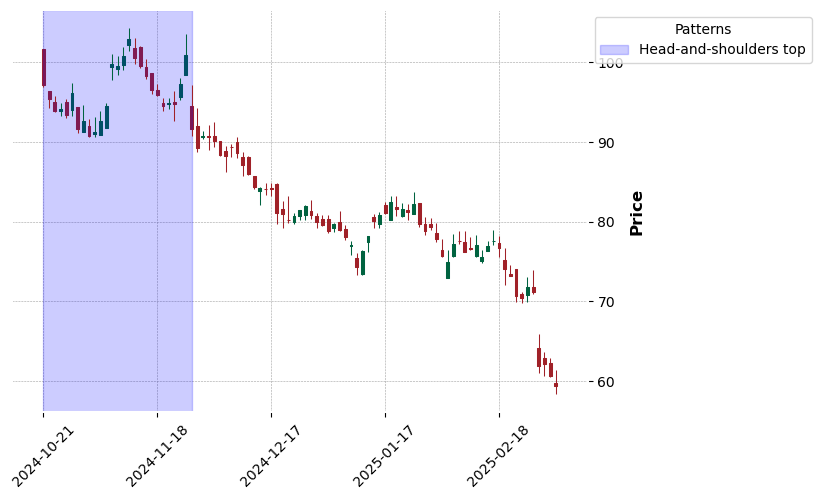

e:\FYP\Candlestick-Chart-Pattern-Detection-FYP\utils\patternLocating.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_Start'] = pd.to_datetime(group['Seg_Start'])
e:\FYP\Candlestick-Chart-Pattern-Detection-FYP\utils\patternLocating.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_End'] = pd.to_datetime(group['Seg_End'])


Pattern Name :  Triangle, symmetrical Pattern Start :  2020-11-09 00:00:00 Pattern End :  2020-12-10 00:00:00


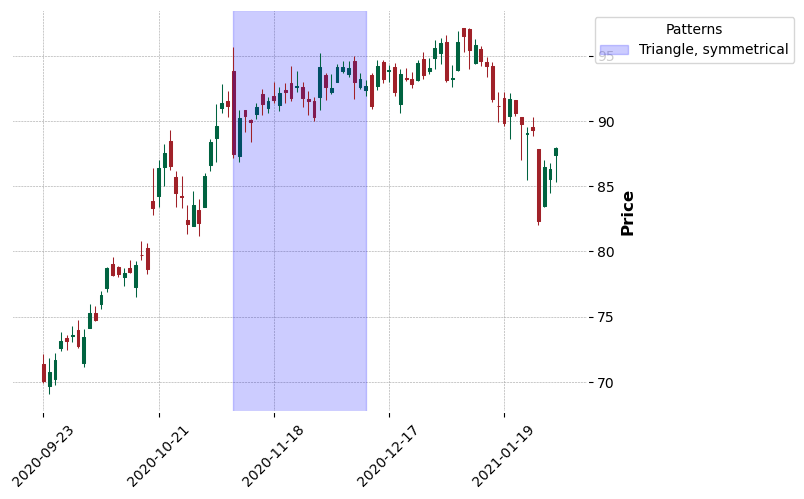

In [19]:
from utils.patternLocating import plot_patterns_for_segment

for id in test_seg_ids_adv:
    test_seg_id = id
    plot_patterns_for_segment(test_seg_id , test_pattern_segment_wise)

Selected model: Width Aug OHLC_mini_rocket_xgb


Processing test segments:   0%|          | 0/2 [00:00<?, ?it/s][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


Tested Win sizes : [100]


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:   17.0s
[Parallel(n_jobs=16)]: Done  91 out of  91 | elapsed:   28.3s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


Tested Win sizes : [100, 97]


...

Tested Win sizes : [100, 97, 69, 49, 35, 25, 18, 13, 9]


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    4.3s
[Parallel(n_jobs=16)]: Done  91 out of  91 | elapsed:   15.1s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


Tested Win sizes : [100, 97, 69, 49, 35, 25, 18, 13, 9, 6]


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done  91 out of  91 | elapsed:   15.2s finished


Length of the segment and the min window size:  135 6
Double Bottom  :
    Clustered Windows :


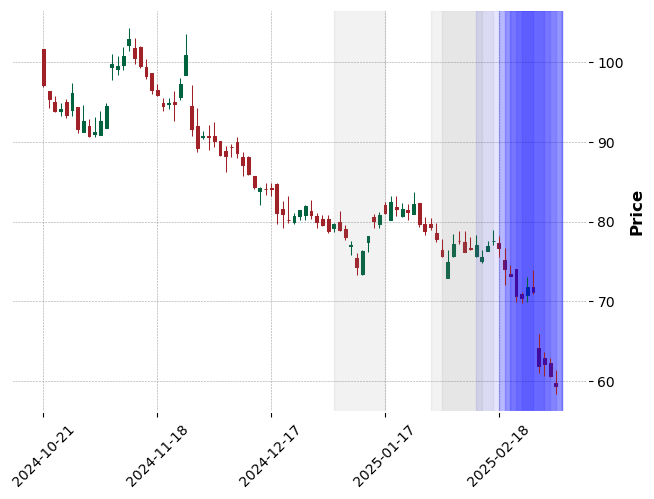

    Finalized Section :


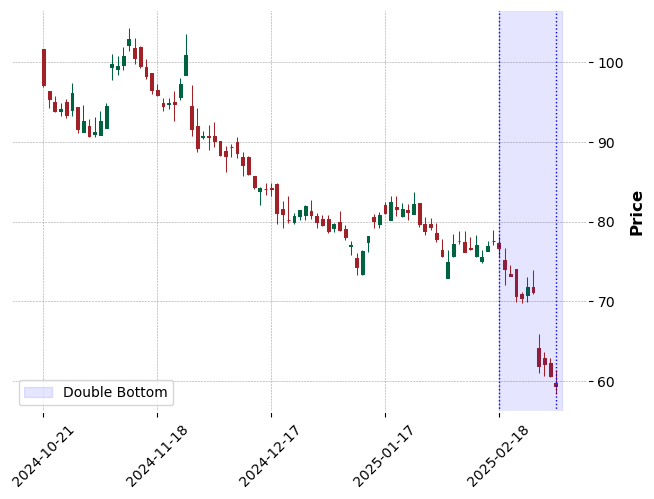

Double Top  :
    Clustered Windows :


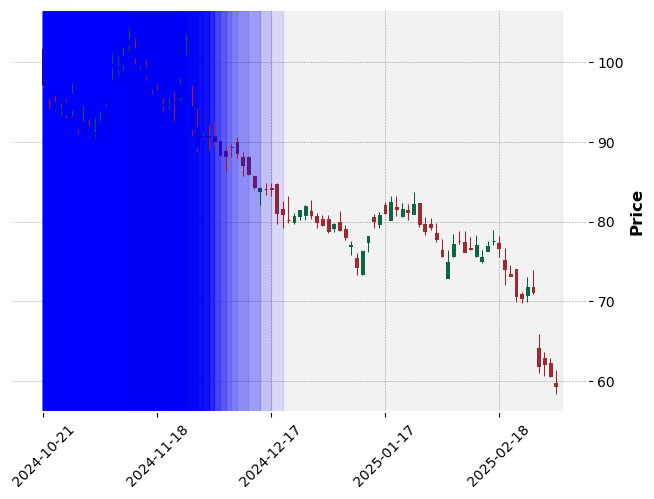

    Finalized Section :


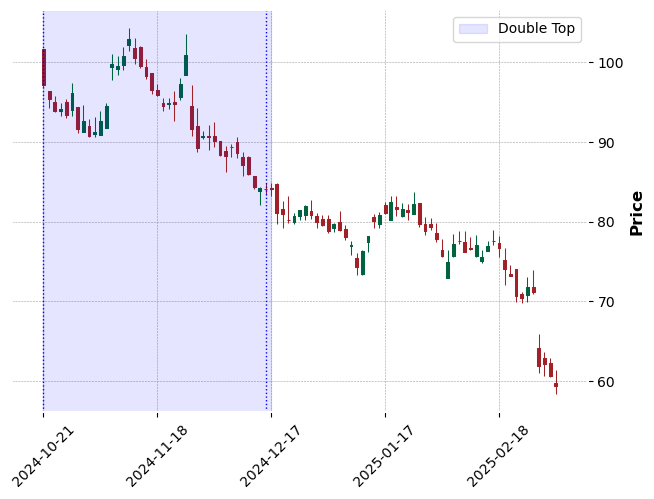

Head-and-shoulders top  :
    Clustered Windows :


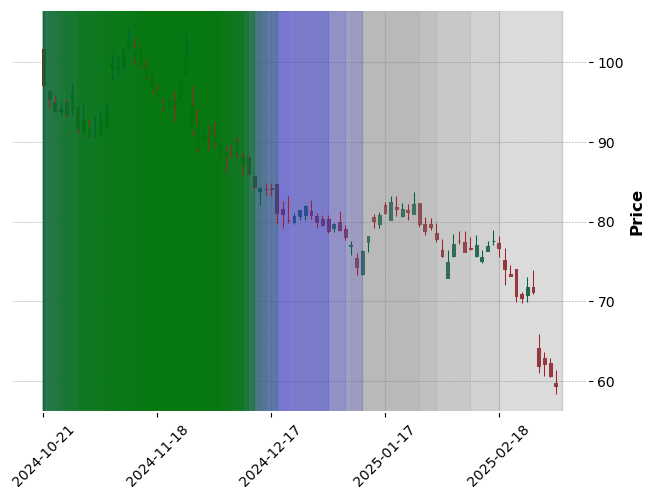

    Finalized Section :


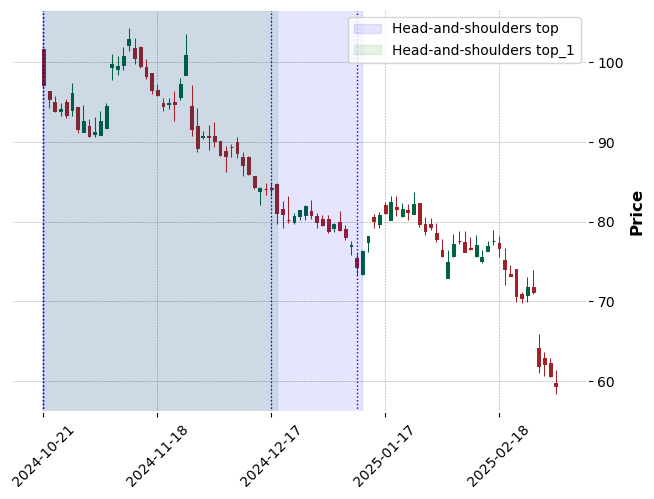

Triangle, symmetrical  :
    Clustered Windows :


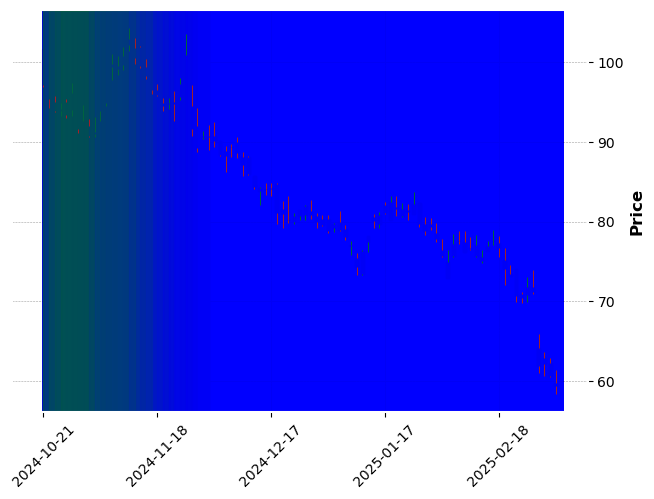

    Finalized Section :


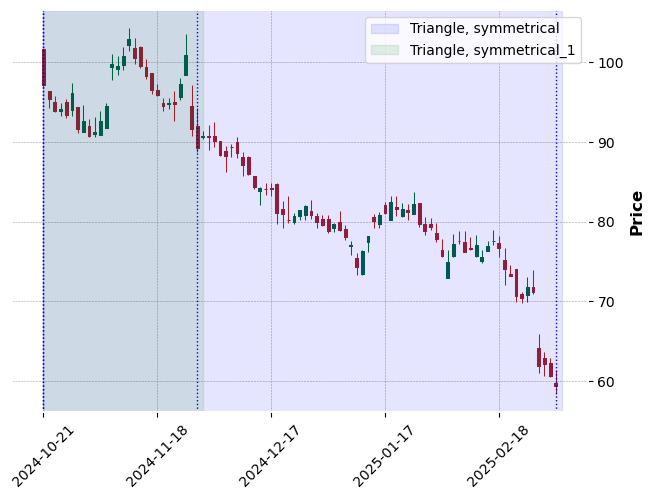

Processing test segments:  50%|█████     | 1/2 [02:48<02:48, 168.49s/it][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


Tested Win sizes : [100]


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done  90 out of  90 | elapsed:   14.9s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


Tested Win sizes : [100, 94]


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    4.0s
[Parallel(n_jobs=16)]: Done  90 out of  90 | elapsed:   15.0s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


...

Tested Win sizes : [100, 94, 67, 48, 34, 24, 17, 12, 9]


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    4.2s
[Parallel(n_jobs=16)]: Done  90 out of  90 | elapsed:   15.7s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


Tested Win sizes : [100, 94, 67, 48, 34, 24, 17, 12, 9, 6]


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    4.2s
[Parallel(n_jobs=16)]: Done  90 out of  90 | elapsed:   15.1s finished


Length of the segment and the min window size:  131 6
Double Bottom  :
    Clustered Windows :


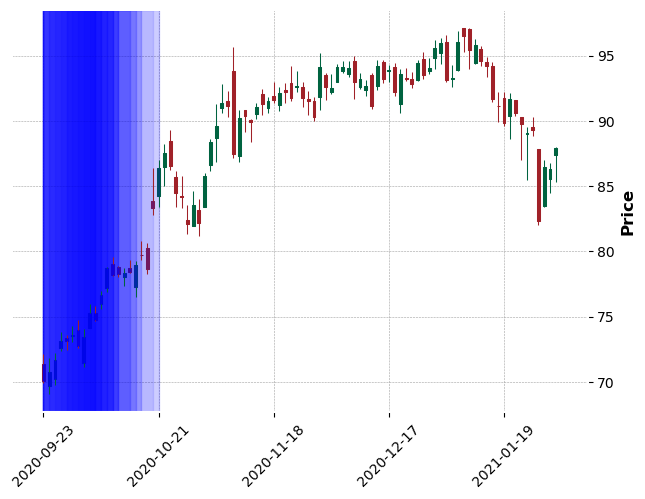

    Finalized Section :


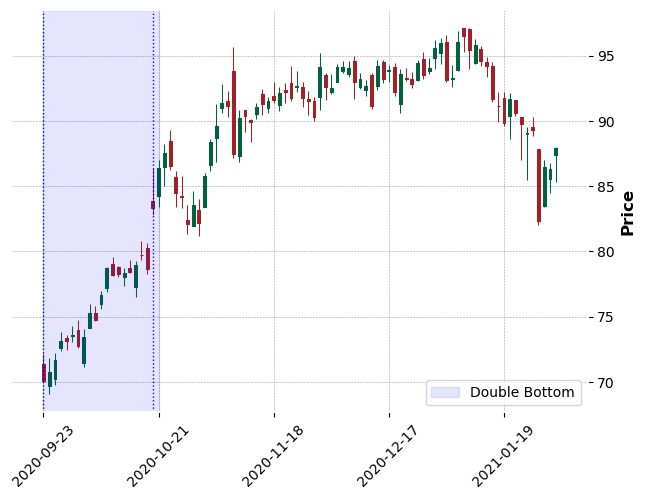

Double Top  :
    Clustered Windows :


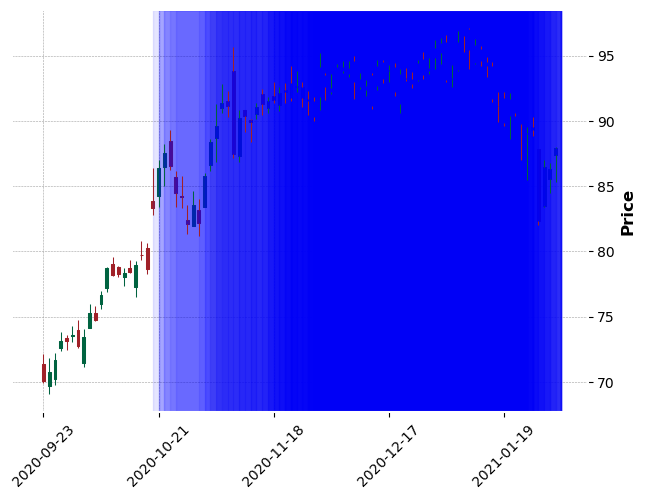

    Finalized Section :


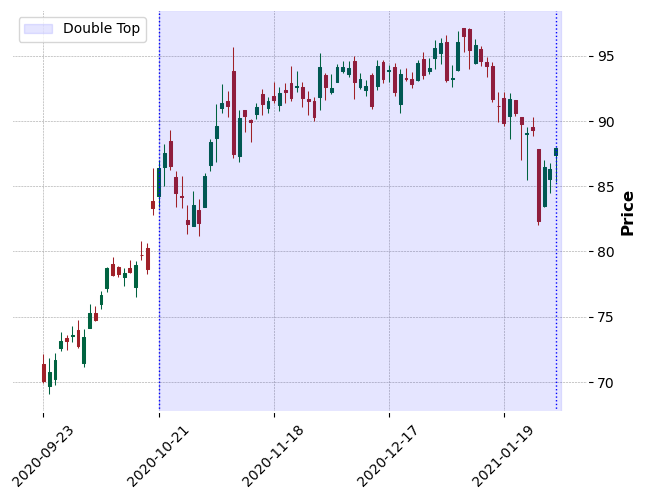

Flag, high and tight  :
    Clustered Windows :


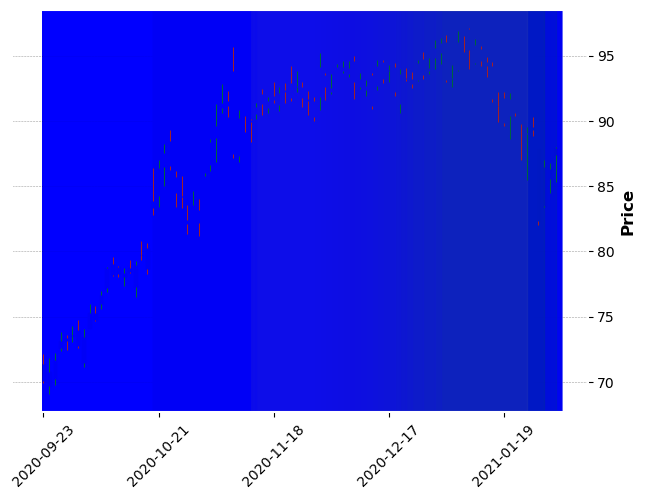

    Finalized Section :


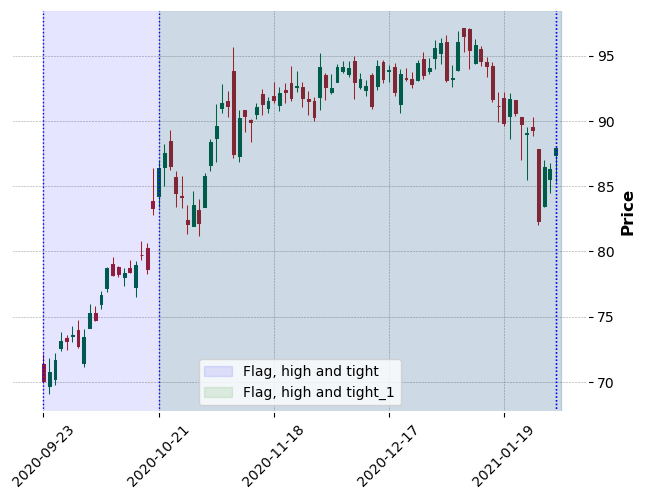

Head-and-shoulders top  :
    Clustered Windows :


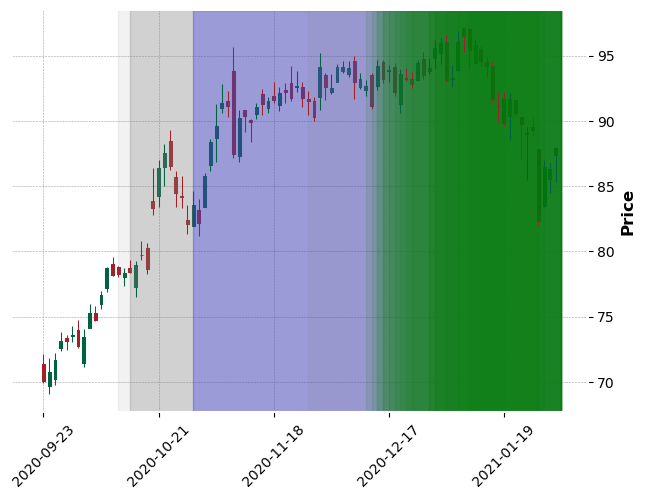

    Finalized Section :


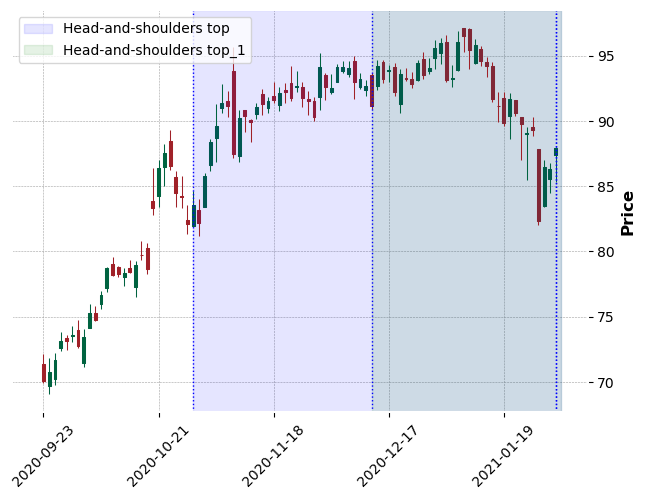

Triangle, symmetrical  :
    Clustered Windows :


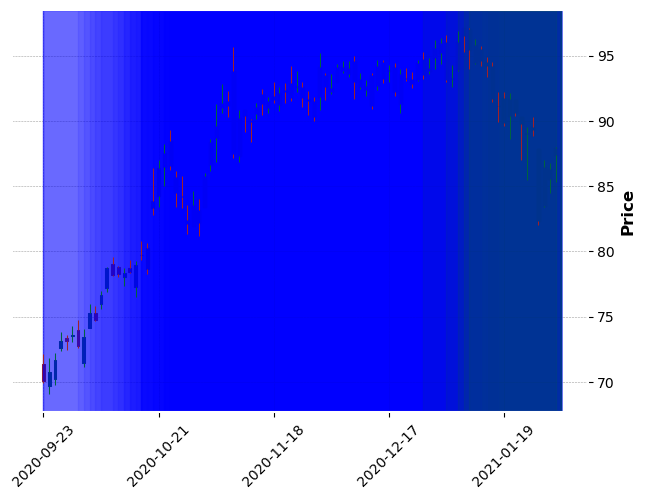

    Finalized Section :


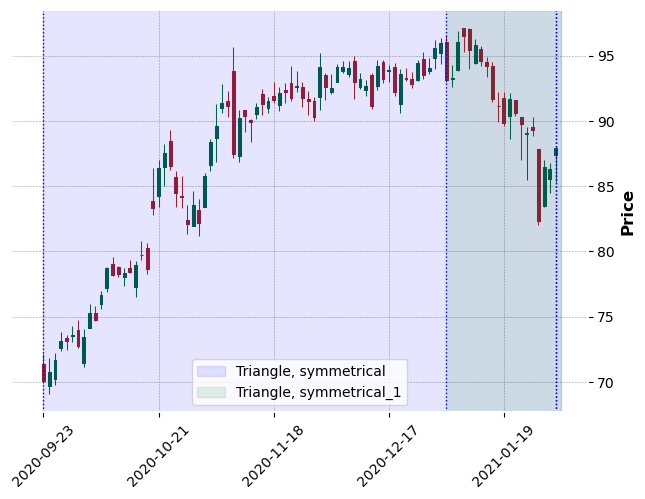

Processing test segments: 100%|██████████| 2/2 [05:27<00:00, 163.68s/it]


Selected model: Length Normed + Width Aug OHLC_mini_rocket_xgb


Processing test segments:   0%|          | 0/2 [00:00<?, ?it/s][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


Tested Win sizes : [100]


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    3.9s
[Parallel(n_jobs=16)]: Done  91 out of  91 | elapsed:   15.2s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


...

Tested Win sizes : [100, 94, 67, 48, 34, 24, 17, 12, 9]


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    4.2s
[Parallel(n_jobs=16)]: Done  90 out of  90 | elapsed:   15.1s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


Tested Win sizes : [100, 94, 67, 48, 34, 24, 17, 12, 9, 6]


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    4.2s
[Parallel(n_jobs=16)]: Done  90 out of  90 | elapsed:   15.1s finished


Length of the segment and the min window size:  131 6
Double Bottom  :
    Clustered Windows :


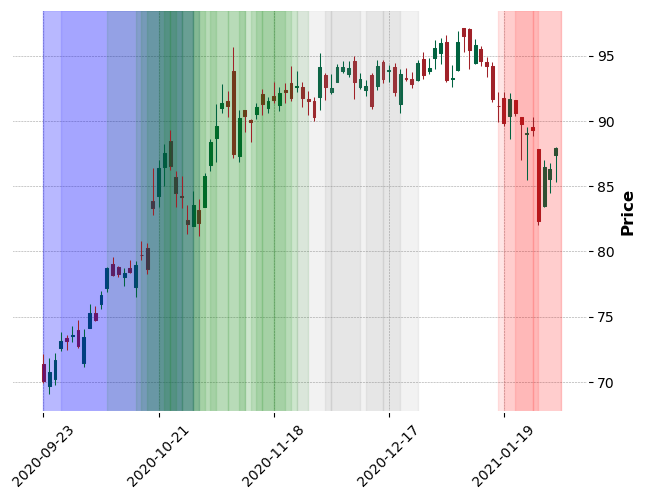

    Finalized Section :


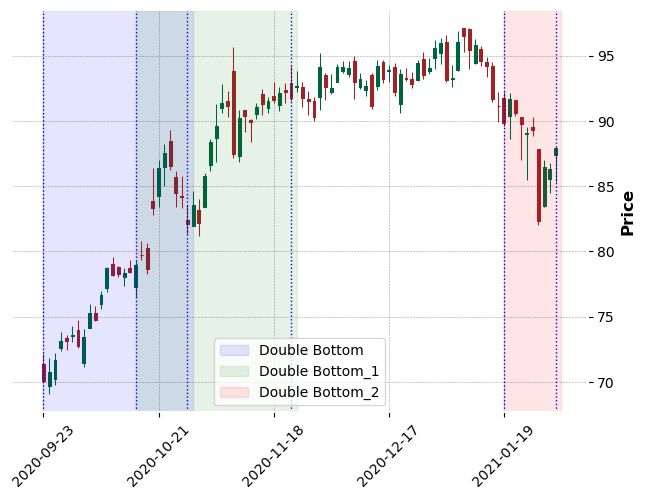

Double Top  :
    Clustered Windows :


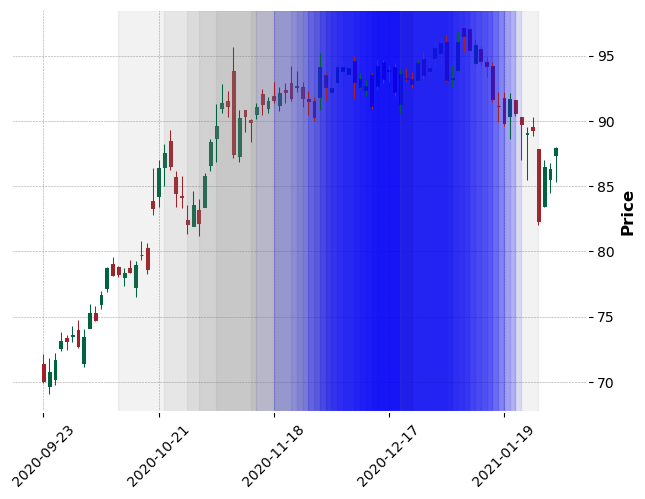

    Finalized Section :


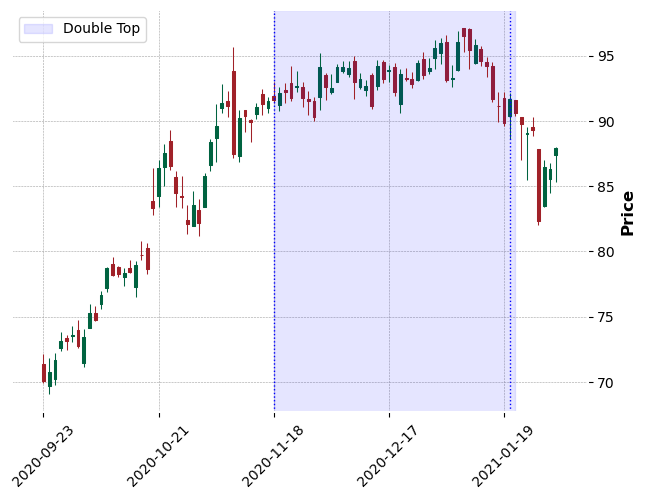

Head-and-shoulders top  :
    Clustered Windows :


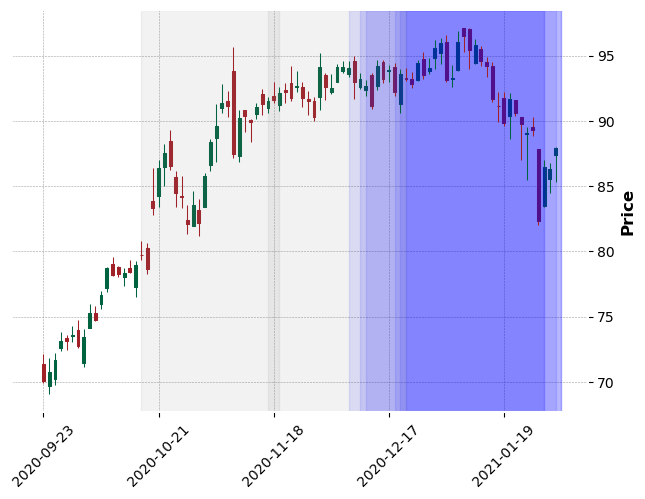

    Finalized Section :


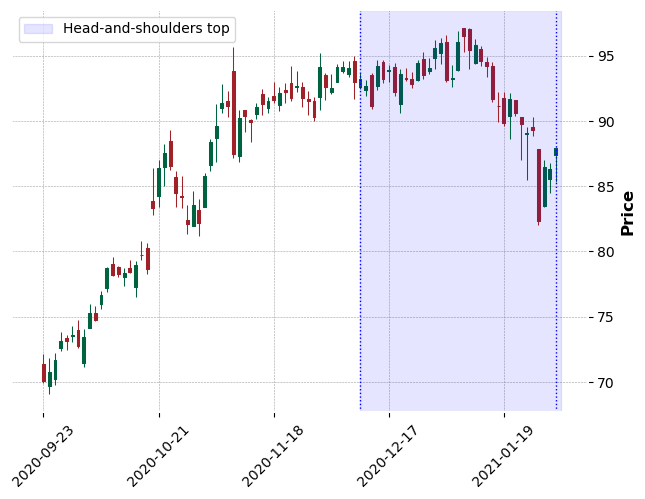

Triangle, symmetrical  :
    Clustered Windows :


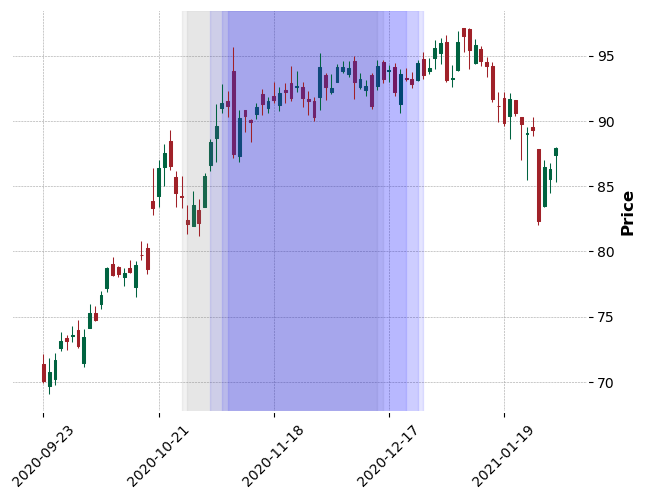

    Finalized Section :


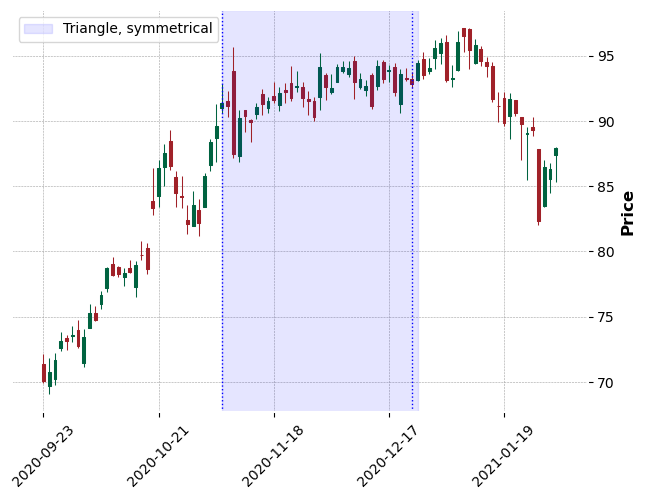

Processing test segments: 100%|██████████| 2/2 [05:32<00:00, 166.15s/it]


In [20]:
import sys

from tqdm import tqdm

from utils.formatAndPreprocessNewPatterns import get_reverse_pattern_encoding
from utils.functionalPatternLocateAndPlot import functional_pattern_filter_and_point_recognition
from utils.patternLocating import  get_ohlc_data_segment, parallel_process_sliding_window, prepare_dataset_for_cluster
from utils.functionalPatternLocateAndPlot import plot_pattern_groups_and_finalized_sections

located_patterns_and_other_info_dict = {}
window_results_dict = {}
pattern_encoding_reversed = get_reverse_pattern_encoding()
path = 'Datasets/OHLC data'

for model_name in selected_models_for_adv:
    print(f"Selected model: {model_name}")
    model = models[model_name]
    
    located_patterns_and_other_info_list = []
    window_results_list = []

    # for seg_id, group in tqdm(grouped, desc="Processing segments"):
        
    #     test_seg_id = seg_id  
    for test_seg_id in tqdm(test_seg_ids_adv, desc="Processing test segments"):
        try :
            # plot_patterns_for_segment(test_seg_id    , test_pattern_segment_wise)
            grouped = test_pattern_segment_wise.groupby('Seg_ID')
            # Select a group
            group = grouped.get_group(test_seg_id)
            
            # convert Seg_Start and Seg_End to datetime
            group.loc[:, 'Seg_Start'] = pd.to_datetime(group['Seg_Start'])
            group.loc[:, 'Seg_End'] = pd.to_datetime(group['Seg_End'])

            Seg_Start = group.iloc[0]['Seg_Start']
            Seg_End = group.iloc[0]['Seg_End']
            seg_len = (Seg_End - Seg_Start).days
            
            win_results_for_each_size = []
            tested_window_sizes = []
            for win_size_proportion in win_size_proportions:
                window_size = seg_len // win_size_proportion
                if window_size < 5:
                    window_size = 5
                elif window_size > 100:
                    window_size = 100
                
                # make sure the win size is a integer
                window_size = int(window_size)
                
                # check if the window size is already tested , because if the size goes below 5 or above 50, it will be set to 10 or 50 respectively
                if window_size in tested_window_sizes:
                    continue
                tested_window_sizes.append(window_size)
                print(f"Tested Win sizes : {tested_window_sizes}")
                
                ohlc_data_segment = get_ohlc_data_segment(test_pattern_segment_wise, test_seg_id, path,group) 
                if ohlc_data_segment is None:
                    print("OHLC Data segment is empty")
                    continue   
                
                len_norm=False
                target_len = target_len
                
                # geet th efirst two words of the model_name 
                model_name_parts = model_name.split(' ')
                data_set_type = model_name_parts[0] + ' ' + model_name_parts[1]
                data_set_type
                
                if data_set_type == "Length Normed":
                    len_norm=True
                
                win_results_df = parallel_process_sliding_window(ohlc_data_segment, model, probability_threshold,stride, pattern_encoding_reversed,group,test_seg_id,window_size, padding_proportion, len_norm, target_len)
                            
                if win_results_df is None:
                    print("Window results dataframe is empty")
                    continue
                win_results_df["Window_Size"] = window_size
                
                win_results_for_each_size.append(win_results_df)
                
            win_results_df_conc = pd.concat(win_results_for_each_size, ignore_index=True)
                
            window_results_list.append(win_results_df_conc)
            
            predicted_patterns = prepare_dataset_for_cluster(ohlc_data_segment, win_results_df_conc)
            if predicted_patterns is None:
                print("Predicted patterns dataframe is empty")
            # print("Predicted Patterns :",predicted_patterns)
            cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, eps=eps, min_samples=min_samples,win_width_proportion=win_width_proportion)
            if cluster_labled_windows_df is None or interseced_clusters_df is None:
                print("Clustered windows dataframe is empty")
                continue
                
            located_patterns_and_other_info = functional_pattern_filter_and_point_recognition(interseced_clusters_df)
            if located_patterns_and_other_info is None:
                print("Located patterns and other info dataframe is empty")
                continue
            # plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, test_seg_id)
            
            # drop teh rows of Chart patterns with the name 'No Pattern' , then print how many rows were dropped
            num_no_patterns = len(located_patterns_and_other_info[located_patterns_and_other_info['Chart Pattern'] == 'No Pattern'])
            # if num_no_patterns > 0:
                # print(f"Number of rows dropped for segment ID {seg_id} : {num_no_patterns}")
            located_patterns_and_other_info = located_patterns_and_other_info[located_patterns_and_other_info['Chart Pattern'] != 'No Pattern']

            plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, test_seg_id)
            located_patterns_and_other_info_list.append(located_patterns_and_other_info)
        except:
            print("Error in segment ID: ",test_seg_id,"error : ",sys.exc_info()[0])
            continue

    located_patterns_and_other_info_final_df = pd.concat(located_patterns_and_other_info_list)
    window_results_all_df = pd.concat(window_results_list)
    
    located_patterns_and_other_info_dict[model_name] = located_patterns_and_other_info_final_df
    window_results_dict[model_name] = window_results_all_df
            

    
    

In [21]:
located_patterns_and_other_info_dict['Length Normed + Width Aug OHLC_mini_rocket_xgb']

,Seg_ID,Symbol,Chart Pattern,Cluster,Start,End,Seg_Start,Seg_End,Calc_Start,Calc_End
0,98,CCK,Double Bottom,0,2020-09-23,2020-10-28,2020-09-23,2021-02-01,2020-09-23,2020-10-28
1,98,CCK,Double Bottom,1,2020-10-15,2020-11-23,2020-09-23,2021-02-01,2020-10-15,2020-11-23
2,98,CCK,Double Bottom,2,2021-01-19,2021-02-01,2020-09-23,2021-02-01,2021-01-19,2021-02-01
3,98,CCK,Double Top,0,2020-11-18,2021-01-20,2020-09-23,2021-02-01,2020-11-18,2021-01-20
4,98,CCK,Head-and-shoulders top,0,2020-12-10,2021-02-01,2020-09-23,2021-02-01,2020-12-10,2021-02-01
6,98,CCK,"Triangle, symmetrical",0,2020-11-05,2020-12-23,2020-09-23,2021-02-01,2020-11-05,2020-12-23


### Saving data to eval and tune


In [22]:
# create Datasets/New_pattern_set_data/Adv_Method2_init/ folder if not exists
import os

test_name = "Adv_Method_win_size_base_clustering"
data_dir = f"Datasets/New_pattern_set_data/{test_name}/"

if not os.path.exists(data_dir):
    os.makedirs(data_dir)

# oop through the model names and get and save located_patterns_and_other_info_dfs and window_results_dfs to cs
for model_name in located_patterns_and_other_info_dict.keys():
    located_patterns_and_other_info_df = located_patterns_and_other_info_dict[model_name]
    window_results_df = window_results_dict[model_name]
    
    # save the dfs to csv
    located_patterns_and_other_info_df.to_csv(f"{data_dir}located_patterns_and_other_info_{model_name}.csv", index=False)
    window_results_df.to_csv(f"{data_dir}window_results_{model_name}.csv", index=False)
    
selected_test_pattern_segment_wise_adv.to_csv(f"{data_dir}test_pattern_segment_wise.csv", index=False)

## Evaluate


In [23]:
from utils.eval import intersection_over_union , mean_abselute_error
from utils.formatAndPreprocessNewPatterns import get_pattern_list
chart_patterns = get_pattern_list()

In [24]:
test_patterns = pd.read_csv("Datasets/New_pattern_set_data/test_df.csv" )

test_patterns_without_no_pattern = test_patterns[test_patterns['Chart Pattern'] != "No Pattern"].copy()
# rename the Unnamed: 0 column to Instance
test_patterns_without_no_pattern.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)
# rename the Unnamed: 0 column to Instance
selected_test_pattern_segment_wise_adv.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)
selected_instances = selected_test_pattern_segment_wise_adv['Instance'].unique()
selected_test_patterns_without_no_pattern = test_patterns_without_no_pattern[test_patterns_without_no_pattern['Instance'].isin(selected_instances)]

C:\Users\gwiku\AppData\Local\Temp\ipykernel_38776\3363097457.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_pattern_segment_wise_adv.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)


In [25]:

test_ids_rows_count_sum = selected_test_pattern_segment_wise_adv.groupby('Seg_ID').size().sum()

# per pattern row count in to a dict
pattern_row_count = {}
for pattern in chart_patterns:
    pattern_row_count[pattern] = selected_test_pattern_segment_wise_adv[selected_test_pattern_segment_wise_adv['Chart Pattern'] == pattern].shape[0]
    
pattern_row_count

{'Double Top': 0,
 'Double Bottom': 0,
 'Triangle, symmetrical': 1,
 'Head-and-shoulders top': 1,
 'Head-and-shoulders bottom': 0,
 'Flag, high and tight': 0,
 'No Pattern': 0}

In [26]:
from tqdm import tqdm
import pandas as pd
from utils.eval import get_model_eval_res

model_eval_results_dict = get_model_eval_res(located_patterns_and_other_info_dict,window_results_dict,selected_models_for_adv,selected_test_patterns_without_no_pattern)
model_eval_results_dict


 Selected model: Width Aug OHLC_mini_rocket_xgb
Processing row 472/1
 Selected model: Length Normed + Width Aug OHLC_mini_rocket_xgb
Processing row 472/1

{'Width Aug OHLC_mini_rocket_xgb': {'number_of_properly_located_patterns': {},
  'iou_for_each_properly_detected_pattern': {},
  'mae_for_each_properly_detected_pattern': {}},
 'Length Normed + Width Aug OHLC_mini_rocket_xgb': {'number_of_properly_located_patterns': {},
  'iou_for_each_properly_detected_pattern': {},
  'mae_for_each_properly_detected_pattern': {}}}


==================== Model: Width Aug OHLC_mini_rocket_xgb ====================
Overall Recall: 0.0000
Overall Precision: 0.0000
Overall F1 Score: 0.0000
Overall Mean Absolute Error: 0.0000
Overall Mean Intersection over Union: 0.0000

==================== Model: Length Normed + Width Aug OHLC_mini_rocket_xgb ====================
Overall Recall: 0.0000
Overall Precision: 0.0000
Overall F1 Score: 0.0000
Overall Mean Absolute Error: 0.0000
Overall Mean Intersection over Union: 0.0000

--- Comprehensive Model Comparison ---


e:\FYP\Candlestick-Chart-Pattern-Detection-FYP\utils\eval.py:341: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.88])  # Adjusted rect to account for title and legend


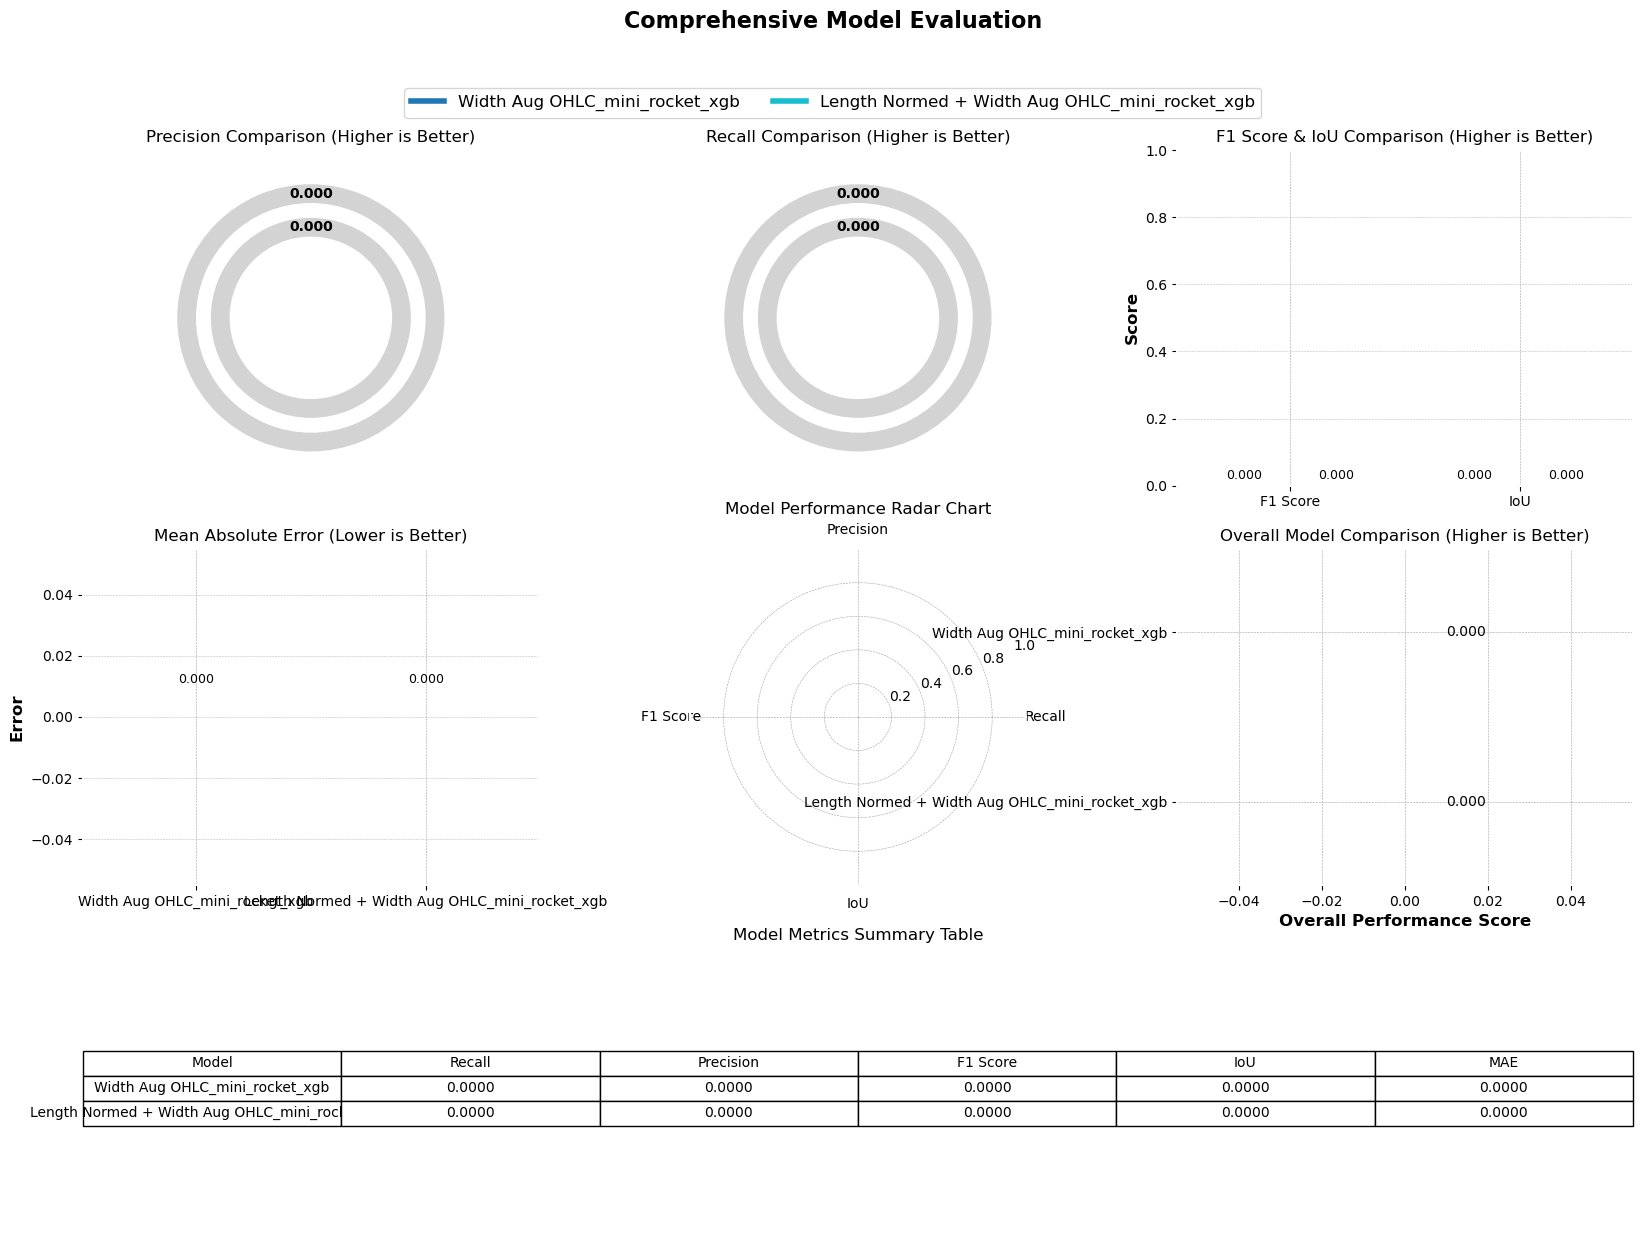

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from utils.eval import evaluate_all_models

all_metrics = evaluate_all_models(model_eval_results_dict, pattern_row_count, test_patterns, located_patterns_and_other_info_dict)
figure = all_metrics[1]

## Testing the clusters


In [ ]:
win_results_df_conc

In [ ]:
import importlib
import utils.patternLocating

importlib.reload(utils.patternLocating)


In [ ]:
from utils.patternLocating import plot_patterns_for_segment

test_seg_id = test_seg_ids_adv[0]
plot_patterns_for_segment(test_seg_id , test_pattern_segment_wise)

In [ ]:
from utils.functionalPatternLocateAndPlot import plot_pattern_groups_and_finalized_sections

predicted_patterns = prepare_dataset_for_cluster(ohlc_data_segment, win_results_df_conc)
if predicted_patterns is None:
    print("Predicted patterns dataframe is empty")
# print("Predicted Patterns :",predicted_patterns)
cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, eps=eps, min_samples=min_samples,win_width_proportion=win_width_proportion)
if cluster_labled_windows_df is None or interseced_clusters_df is None:
    print("Clustered windows dataframe is empty")
    # continue
    
located_patterns_and_other_info = functional_pattern_filter_and_point_recognition(interseced_clusters_df)
if located_patterns_and_other_info is None:
    print("Located patterns and other info dataframe is empty")
    # continue
# plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, test_seg_id)

In [ ]:
cluster_labled_windows_df

In [ ]:
x_end = predicted_patterns['Center'].max() + 10
y_end = predicted_patterns['Window_Size'].max() + 10

for pattern, group in cluster_labled_windows_df.groupby('Chart Pattern'):
    plt.figure(figsize=(10, 6))
    
    # Use the Probability column to determine point sizes
    # Multiply by a scaling factor to make the difference more visible
    point_sizes = (group['Probability'] ** 5) * 1000 # Adjust the multiplier as needed
    
    plt.scatter(
        group['Center'], 
        group['Window_Size'], 
        c=group['Cluster'], 
        s=point_sizes,  # Size based on probability
        cmap='viridis', 
        alpha=0.5
    )
    
    plt.title(f'Window Size and Center for {pattern}')
    plt.xlabel('Center')
    plt.ylabel('Window Size')
    plt.colorbar(label='Cluster')
    
    # Add legend or note about point sizes
    plt.figtext(0.15, 0.02, "Point size represents probability", ha="center")
    
    # Set axis ranges
    plt.xlim(0, x_end)
    plt.ylim(0, y_end)

    plt.show()

In [ ]:
x_start = predicted_patterns['Center'].min()
x_end = predicted_patterns['Center'].max() 
y_start = predicted_patterns['Window_Size'].min()
y_end = predicted_patterns['Window_Size'].max()

for pattern, group in cluster_labled_windows_df.groupby('Chart Pattern'):
    plt.figure(figsize=(10, 6))
    plt.scatter(
        ((group['Center'] - x_start)/(x_end - x_start)), 
        ((group['Window_Size'] - y_start)/(y_end - y_start))/10, 
        c=group['Cluster'], cmap='viridis', alpha=0.5
    )
    plt.title(f'Window Size and Center for {pattern}')
    plt.xlabel('Center')
    plt.ylabel('Window Size')
    plt.colorbar(label='Cluster')
    
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.show()

In [ ]:
x_end = predicted_patterns['Center'].max() +10
y_end = predicted_patterns['Window_Size'].max() +10
for pattern, group in cluster_labled_windows_df.groupby('Chart Pattern'):
    plt.figure(figsize=(10, 6))
    plt.scatter(group['Center'], group['Window_Size'], c=group['Cluster'], cmap='viridis', alpha=0.5)
    plt.title(f'Window Size and Center for {pattern}')
    plt.xlabel('Center')
    plt.ylabel('Window Size')
    plt.colorbar(label='Cluster')
    
    # 👇 Set your custom axis ranges here
    plt.xlim(0, x_end)  # e.g., plt.xlim(0, 100)
    plt.ylim(0, y_end)  # e.g., plt.ylim(0, 150)

    plt.show()


In [ ]:
window_results_list[0]

In [ ]:
import sys

from tqdm import tqdm

from formatAndPreprocessNewPatterns import get_reverse_pattern_encoding
from utils.functionalPatternLocateAndPlot import functional_pattern_filter_and_point_recognition
from utils.patternLocating import cluster_windows, get_ohlc_data_segment, parallel_process_sliding_window, prepare_dataset_for_cluster

located_patterns_and_other_info_dict = {}
window_results_dict = {}
pattern_encoding_reversed = get_reverse_pattern_encoding()
path = 'Datasets/OHLC data'

for model_name in selected_models_for_adv:
    print(f"Selected model: {model_name}")
    model = models[model_name]
    
    located_patterns_and_other_info_list = []
    window_results_list = []

    # for seg_id, group in tqdm(grouped, desc="Processing segments"):
        
    #     test_seg_id = seg_id  
    for test_seg_id in tqdm(test_seg_ids_adv, desc="Processing test segments"):
        try :
            # plot_patterns_for_segment(test_seg_id    , test_pattern_segment_wise)
            grouped = test_pattern_segment_wise.groupby('Seg_ID')
            # Select a group
            group = grouped.get_group(test_seg_id)

            Seg_Start = group.iloc[0]['Seg_Start']
            Seg_End = group.iloc[0]['Seg_End']
            seg_len = (Seg_End - Seg_Start).days

            window_size = seg_len // win_size_proportion
            # print(f"Win size : {window_size}")
            if window_size < 10:
                window_size = 10
            # elif window_size > 30:
            #     window_size = 30
                
            ohlc_data_segment = get_ohlc_data_segment(test_pattern_segment_wise, test_seg_id, path,group) 
            if ohlc_data_segment is None:
                print("OHLC Data segment is empty")
                continue   
            
            len_norm=False
            target_len = target_len
            
            # geet th efirst two words of the model_name 
            model_name_parts = model_name.split(' ')
            data_set_type = model_name_parts[0] + ' ' + model_name_parts[1]
            data_set_type
            
            if data_set_type == "Length Normed":
                len_norm=True
            
            win_results_df = parallel_process_sliding_window(ohlc_data_segment, model, probability_threshold,stride, pattern_encoding_reversed,group,test_seg_id,window_size, padding_proportion, len_norm, target_len)
            
            if win_results_df is None:
                print("Window results dataframe is empty")
                continue
            window_results_list.append(win_results_df)
            # plot_sliding_steps(win_results_df ,ohlc_data_segment,probability_threshold ,test_seg_id)
            predicted_patterns = prepare_dataset_for_cluster(ohlc_data_segment, win_results_df)
            if predicted_patterns is None:
                print("Predicted patterns dataframe is empty")
            # print("Predicted Patterns :",predicted_patterns)
            cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, window_size)
            if cluster_labled_windows_df is None or interseced_clusters_df is None:
                print("Clustered windows dataframe is empty")
                continue
            located_patterns_and_other_info = functional_pattern_filter_and_point_recognition(interseced_clusters_df)
            if located_patterns_and_other_info is None:
                print("Located patterns and other info dataframe is empty")
                continue
            # plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, test_seg_id)
            
            
            
            located_patterns_and_other_info_list.append(located_patterns_and_other_info)
        except:
            print("Error in segment ID: ",test_seg_id,"error : ",sys.exc_info()[0])
            continue

    located_patterns_and_other_info_final_df = pd.concat(located_patterns_and_other_info_list)
    window_results_all_df = pd.concat(window_results_list)
    
    located_patterns_and_other_info_dict[model_name] = located_patterns_and_other_info_final_df
    window_results_dict[model_name] = window_results_all_df
    


# Advanced Search - Larger cover Smaller method


## Load Models


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# load the pipelined model
import os
import joblib
from utils.FixedLengthTransformer import FixedLengthTransformer
# load the saved models from the Models directory
model_dir = "Models"
model_files = [f for f in os.listdir(model_dir) if f.endswith('.joblib')]
models = {}
for model_file in model_files:
    model_name = model_file.split('.')[0]
    models[model_name] = joblib.load(os.path.join(model_dir, model_file))
    
# print the model names
print("Available models:")
for model_name in models.keys():
    print(model_name)

selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb','Length Normed + Width Aug OHLC_mini_rocket_xgb']
# selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb']

Available models:
Width Aug OHLC + traindata Aug_mini_rocket_xgb
Width Aug OHLC_rocket_xgb
Width Aug OHLC_mini_rocket_xgb
Width Aug OHLC + traindata Aug_rocket_xgb
Length Normed + Width Aug OHLC_rocket_xgb
Plane OHLC + traindata Aug_mini_rocket_xgb
Width Aug OHLC + traindata Aug_multi_rocket_xgb
Width Aug OHLC_multi_rocket_xgb
Plane OHLC_rocket_xgb
Plane OHLC + traindata Aug_rocket_xgb
Plane OHLC_mini_rocket_xgb
Plane OHLC_multi_rocket_xgb
Length Normed + Width Aug OHLC_mini_rocket_xgb
Plane OHLC + traindata Aug_multi_rocket_xgb
Length Normed + Width Aug OHLC_multi_rocket_xgb
Length Normed OHLC_multi_rocket_xgb
Length Normed OHLC_mini_rocket_xgb
Length Normed OHLC_rocket_xgb


## Selecting the test sample


In [ ]:
import random
random.seed(69)

test_pattern_segment_wise = pd.read_csv("Datasets/New_pattern_set_data/test_patterns_large_segment_wise.csv")
# convert Seg_Start , Seg_End , Start and End to datetime
test_pattern_segment_wise.loc[:, 'Seg_Start'] = pd.to_datetime(test_pattern_segment_wise['Seg_Start'])
test_pattern_segment_wise.loc[:, 'Seg_End'] = pd.to_datetime(test_pattern_segment_wise['Seg_End'])
test_pattern_segment_wise.loc[:, 'Start'] = pd.to_datetime(test_pattern_segment_wise['Start'])
test_pattern_segment_wise.loc[:, 'End'] = pd.to_datetime(test_pattern_segment_wise['End'])

test_seg_ids_adv = test_pattern_segment_wise['Seg_ID'].unique()
# select random 100 seg ids from the test_seg_ids_adv
test_seg_ids_adv = random.sample(list(test_seg_ids_adv), 100)

selected_test_pattern_segment_wise_adv = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids_adv)]
# selected_test_pattern_segment_wise_adv = test_pattern_segment_wise.copy()

test_ids_rows_count_sum_adv = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids_adv)].groupby('Seg_ID').size().sum()
test_ids_rows_count_sum_adv , len(test_seg_ids_adv)

(118, 100)

## Advance pattern Locating


In [ ]:
# window_size = 20
# win_size_proportion = 5
win_size_proportions = np.round(np.logspace(0, np.log10(20), num=10), 2).tolist()
# Example output: [1.0, 1.58, 2.5, 3.95, 6.25, 9.88, 15.63, 20.0]
padding_proportion = 0.6
stride = 1
probability_threshold = 0.0
# for len norm 
target_len = 30

eps=0.04 # in the dbscan clustering
min_samples=3 # in the dbscan clustering
win_width_proportion=10 # in the dbscan clustering from what amount to divide the width related feature

/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_Start'] = pd.to_datetime(group['Seg_Start'])
/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_End'] = pd.to_datetime(group['Seg_End'])


Pattern Name :  Double Bottom Pattern Start :  2024-08-05 00:00:00 Pattern End :  2024-09-11 00:00:00
Pattern Name :  Double Top Pattern Start :  2024-07-17 00:00:00 Pattern End :  2024-07-31 00:00:00


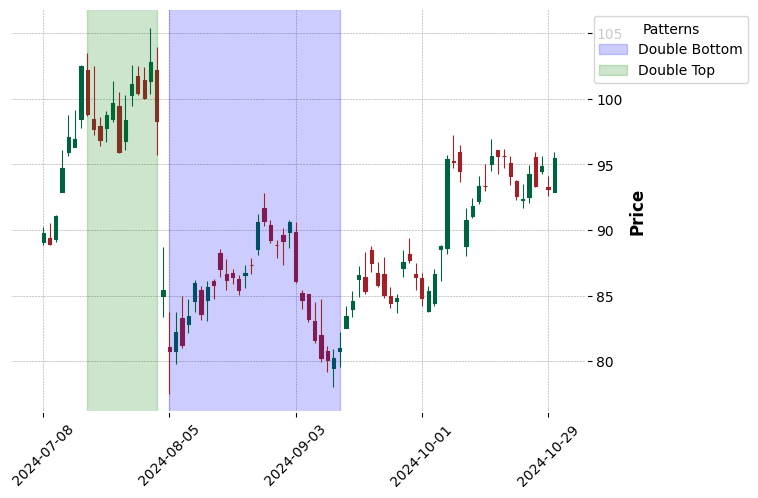

Pattern Name :  Double Bottom Pattern Start :  2023-03-24 00:00:00 Pattern End :  2023-04-06 00:00:00


/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_Start'] = pd.to_datetime(group['Seg_Start'])
/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_End'] = pd.to_datetime(group['Seg_End'])


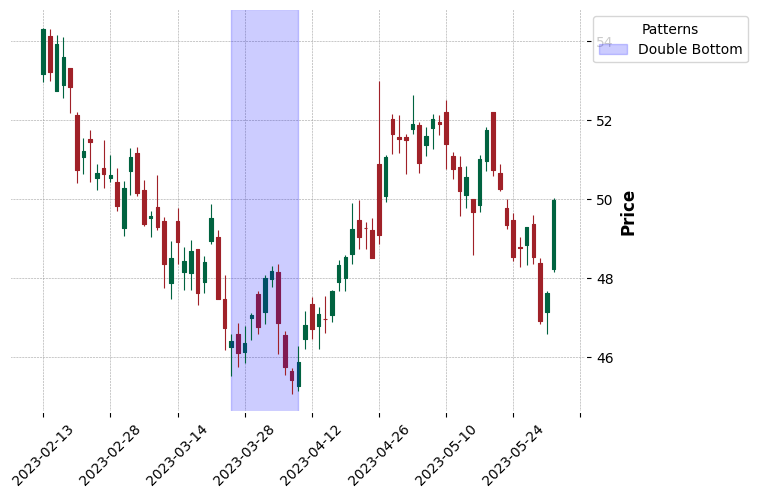

In [ ]:
from utils.patternLocating import plot_patterns_for_segment

plot_count1 = 2

for id in test_seg_ids_adv:
    if plot_count1 >0:
        test_seg_id = id
        plot_patterns_for_segment(test_seg_id , test_pattern_segment_wise)
        plot_count1 -= 1

Selected model: Width Aug OHLC_mini_rocket_xgb


Processing test segments:   0%|          | 0/100 [00:00<?, ?it/s][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:   10.1s
[Parallel(n_jobs=16)]: Done  82 out of  82 | elapsed:   16.8s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.6s
[Parallel(n_jobs=16)]: Done  82 out of  82 | elapsed:    7.7s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done  82 out of  82 | elapsed:    7.2s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done  82 out of  82 | elapsed:    7.4s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.0s
[Parallel(n_jobs=16)]: Done  82 out of  82 | elapsed:    7.1s finished
[Parallel(n_jobs=16)]: Usin

Double Bottom  :
    Clustered Windows :


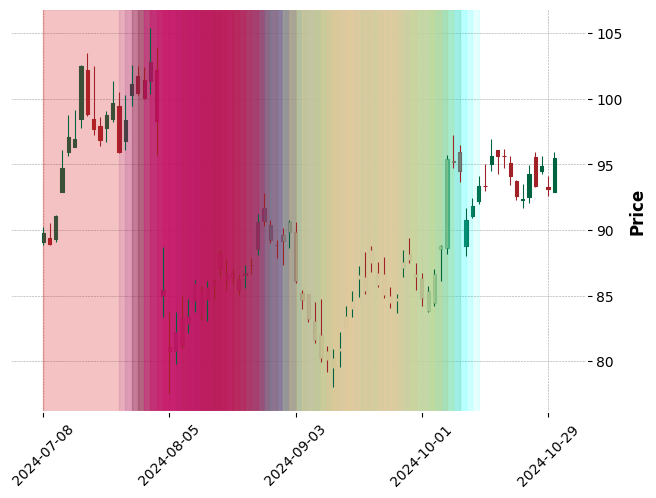

    Finalized Section :


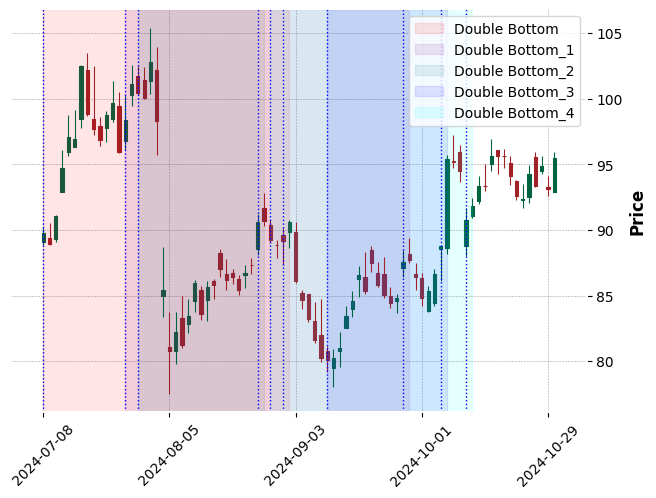

Double Top  :
    Clustered Windows :


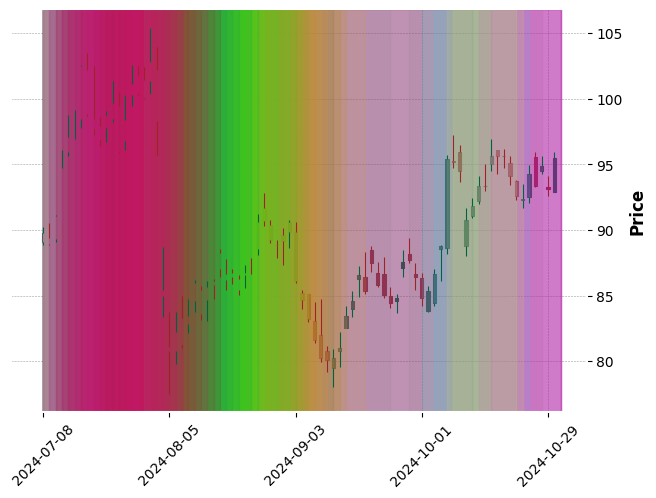

    Finalized Section :


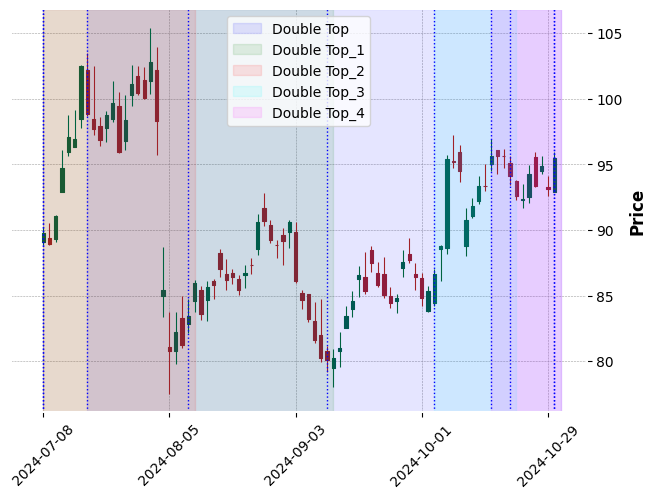

Flag, high and tight  :
    Clustered Windows :


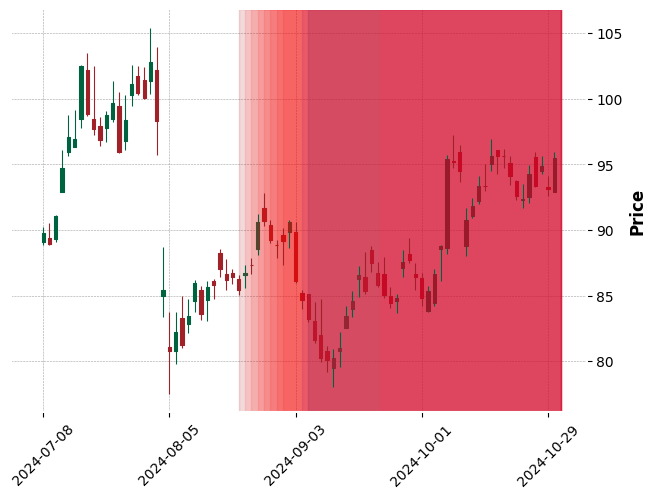

    Finalized Section :


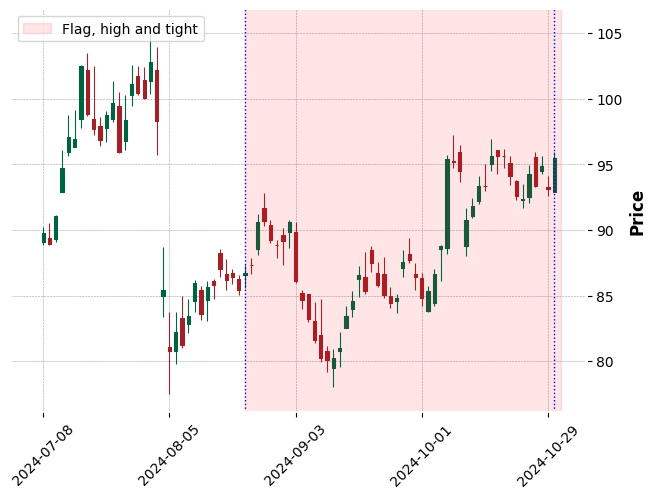

Head-and-shoulders bottom  :
    Clustered Windows :


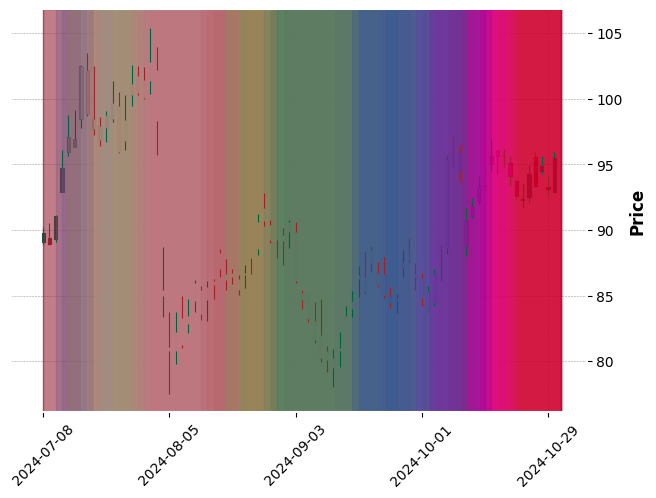

    Finalized Section :


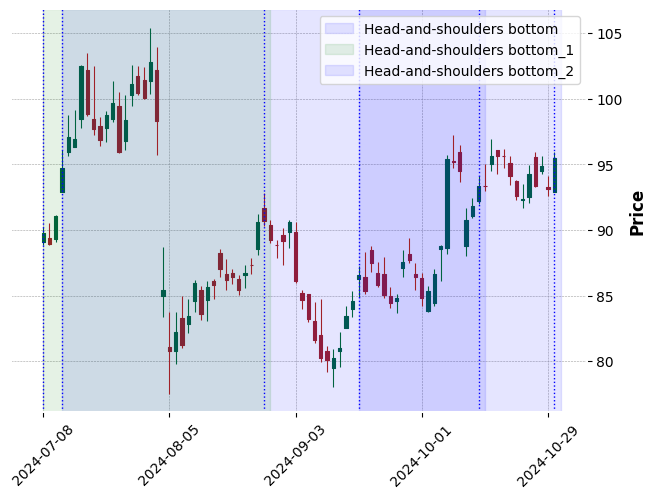

Head-and-shoulders top  :
    Clustered Windows :


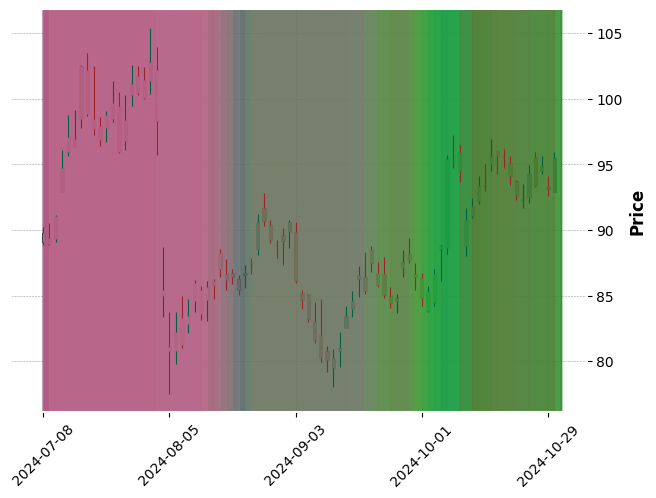

    Finalized Section :


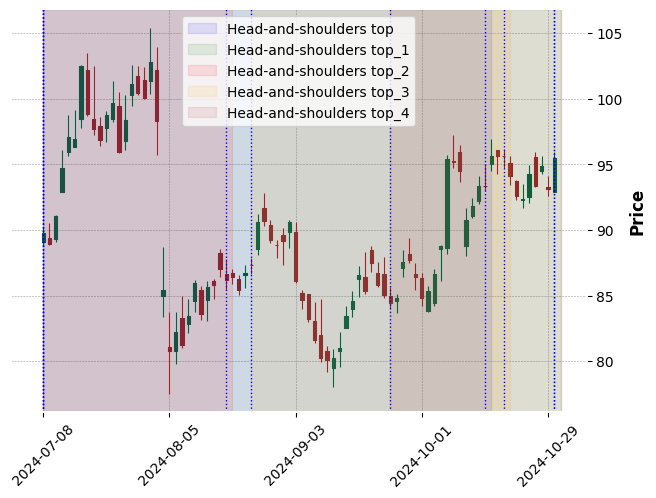

No Pattern  :
    Clustered Windows :


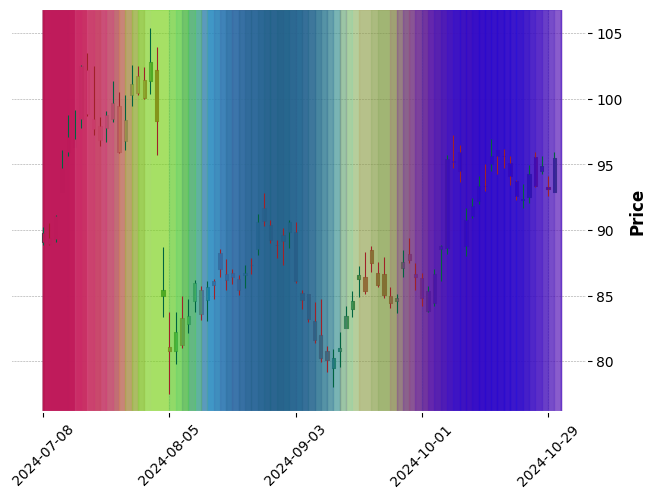

    Finalized Section :


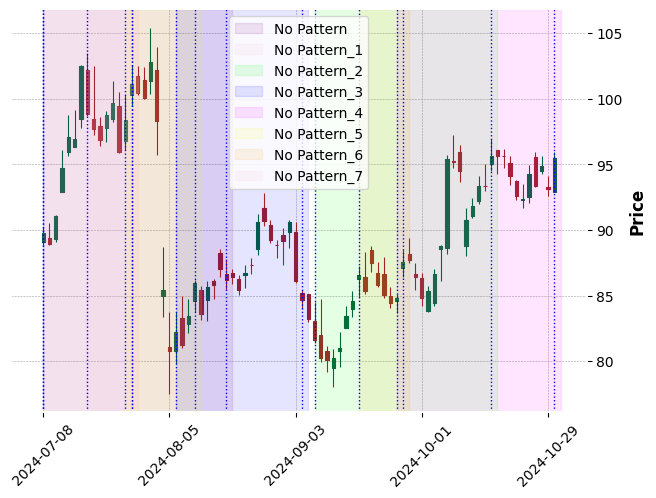

Triangle, symmetrical  :
    Clustered Windows :


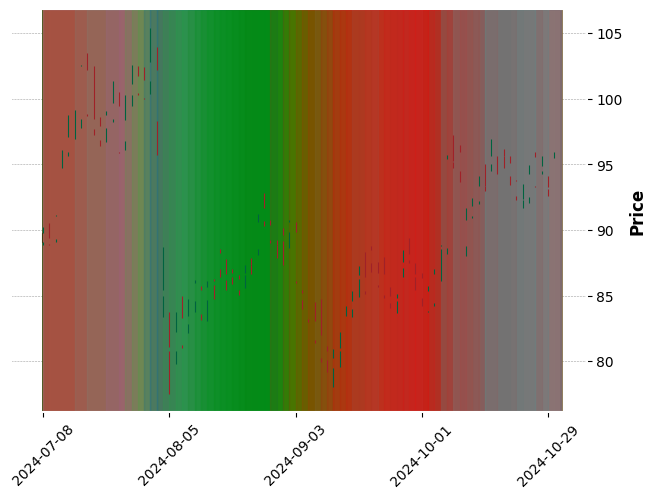

    Finalized Section :


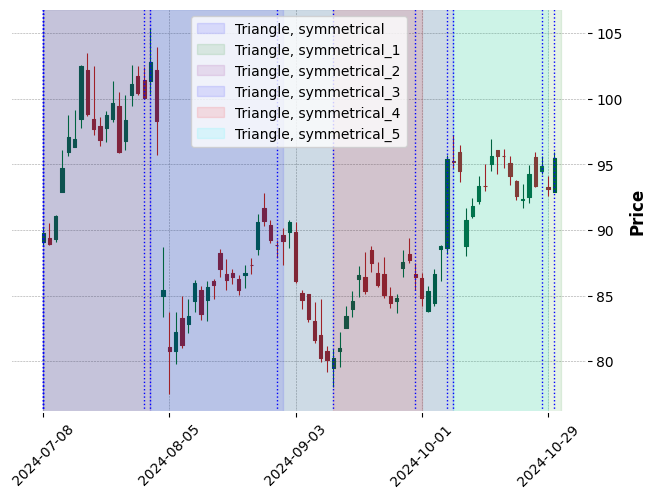

Processing test segments:   1%|          | 1/100 [01:26<2:23:06, 86.73s/it][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done  77 out of  77 | elapsed:    7.1s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done  77 out of  77 | elapsed:    6.8s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.3s
[Parallel(n_jobs=16)]: Done  77 out of  77 | elapsed:    7.0s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done  77 out of  77 | elapsed:    6.6s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Paralle

Double Bottom  :
    Clustered Windows :


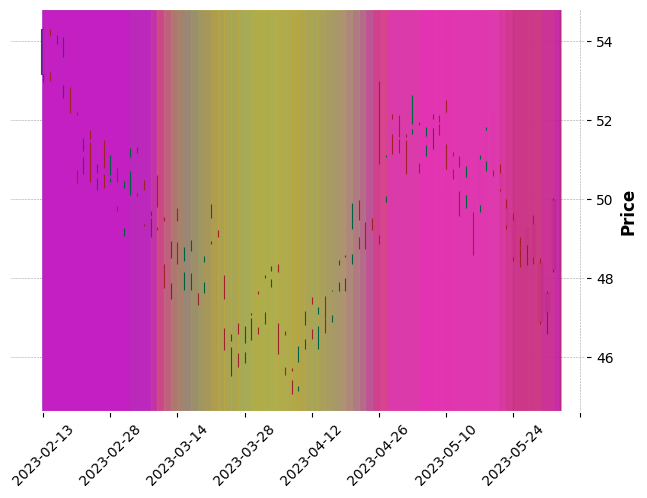

    Finalized Section :


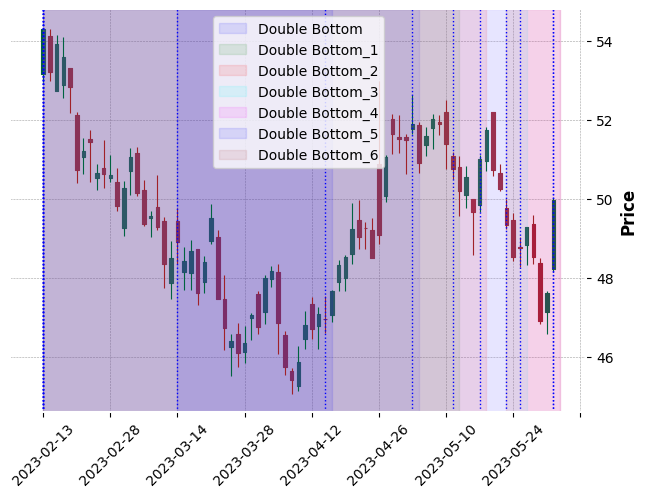

Double Top  :
    Clustered Windows :


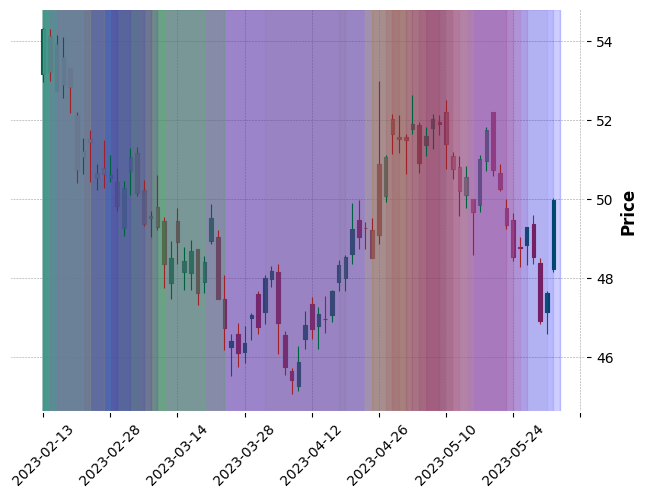

    Finalized Section :


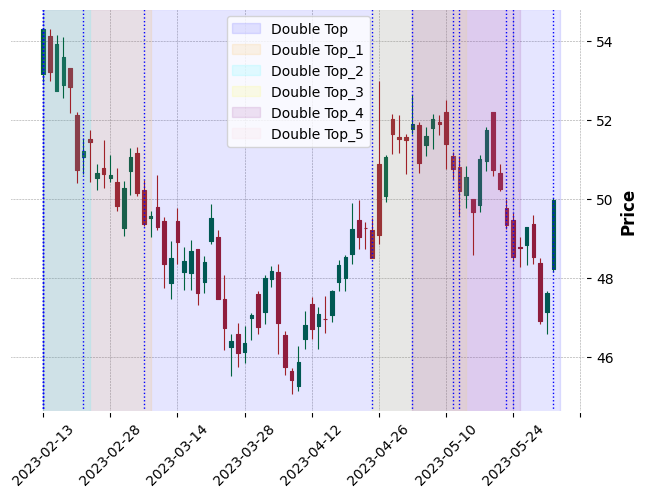

Flag, high and tight  :
    Clustered Windows :


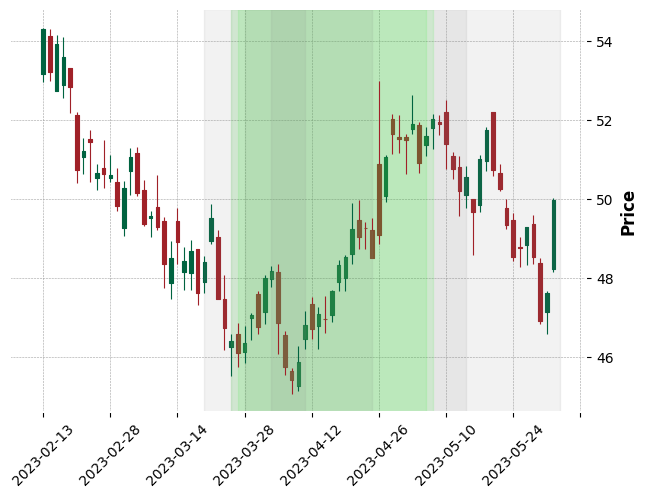

    Finalized Section :


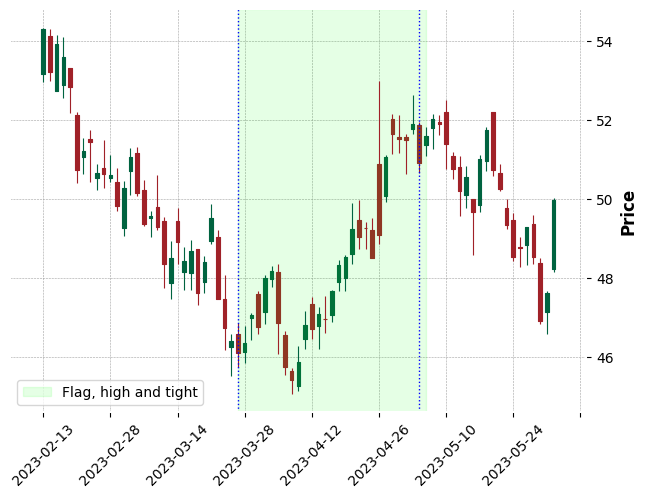

Head-and-shoulders bottom  :
    Clustered Windows :


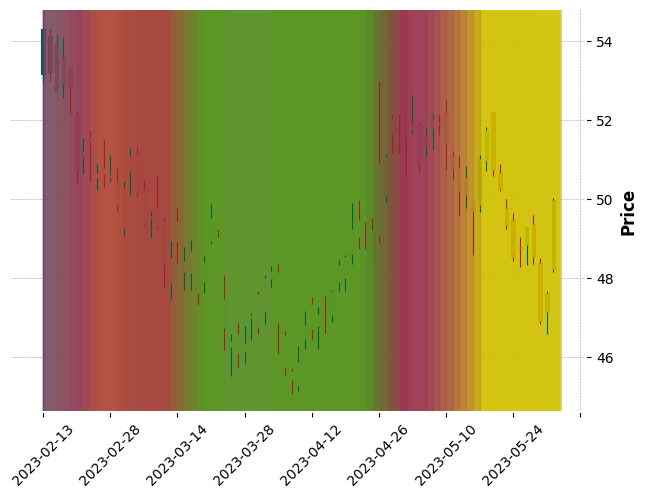

    Finalized Section :


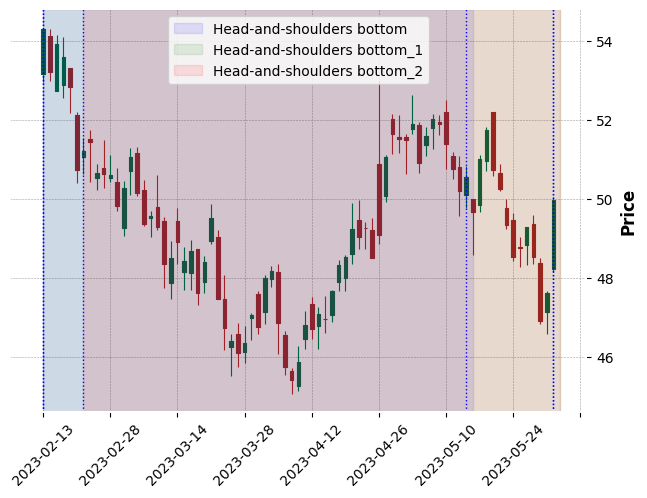

Head-and-shoulders top  :
    Clustered Windows :


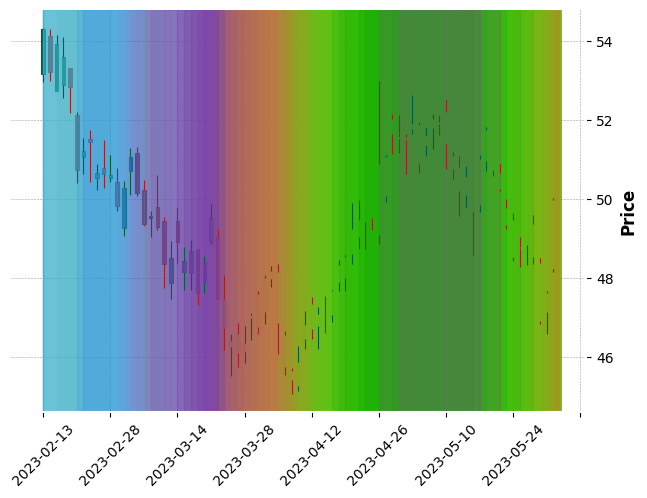

    Finalized Section :


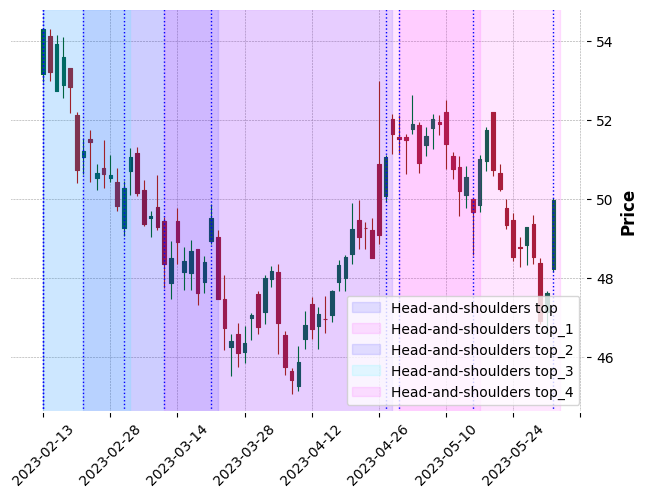

No Pattern  :
    Clustered Windows :


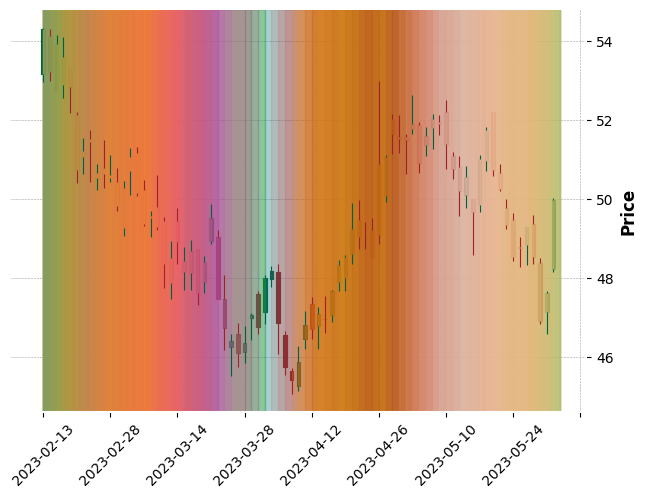

    Finalized Section :


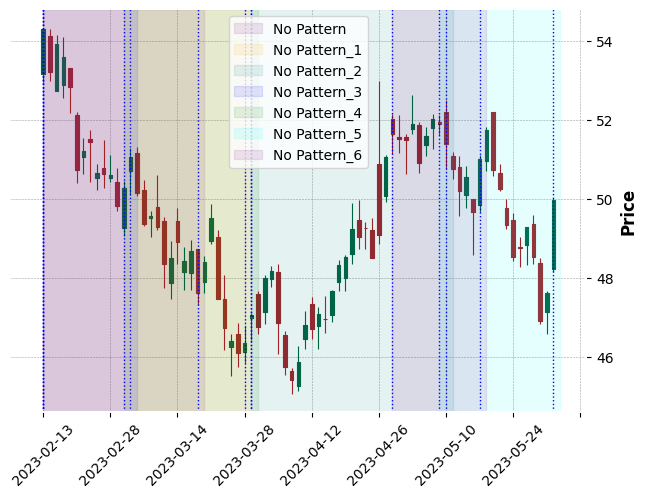

Triangle, symmetrical  :
    Clustered Windows :


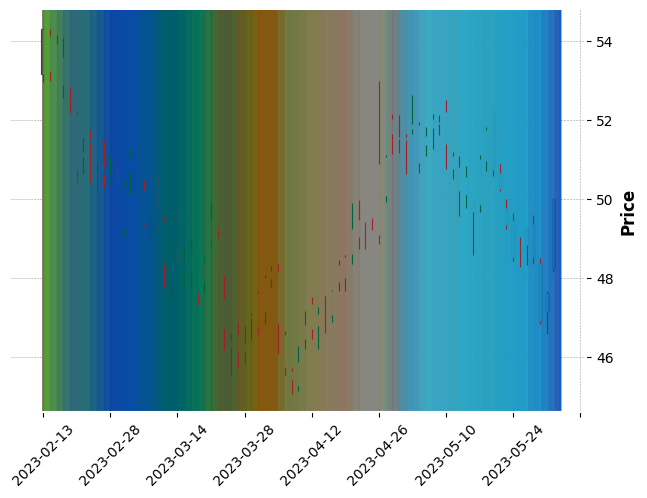

    Finalized Section :


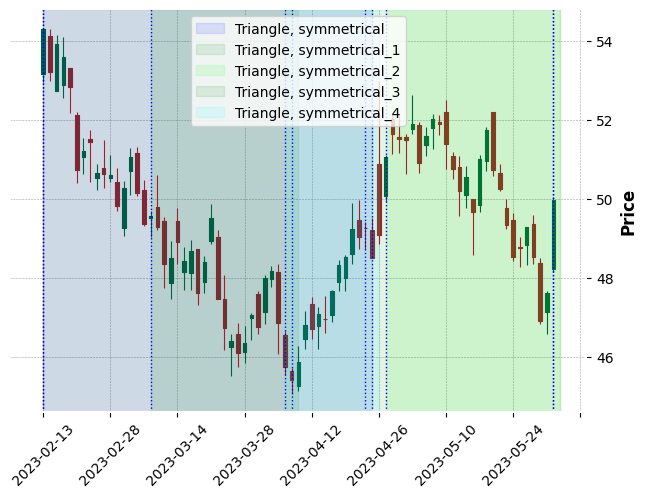

Processing test segments:   2%|▏         | 2/100 [02:32<2:01:10, 74.19s/it][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done  80 out of  80 | elapsed:    7.1s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done  80 out of  80 | elapsed:    7.3s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.3s
[Parallel(n_jobs=16)]: Done  80 out of  80 | elapsed:    6.9s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done  80 out of  80 | elapsed:    6.8s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Paralle

Clustered windows dataframe is empty


[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:    0.5s remaining:    3.3s
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:    1.3s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:    0.9s remaining:    6.2s
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:    1.4s finished
Processing test segments:  66%|██████▌   | 66/100 [57:41<17:44, 31.30s/it][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    3.9s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    4.0s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | ela

Selected model: Length Normed + Width Aug OHLC_mini_rocket_xgb


Processing test segments:   0%|          | 0/100 [00:00<?, ?it/s][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done  82 out of  82 | elapsed:    6.3s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done  82 out of  82 | elapsed:    6.4s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done  82 out of  82 | elapsed:    6.2s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done  82 out of  82 | elapsed:    6.2s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=1

Clustered windows dataframe is empty


[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:    0.7s remaining:    4.8s
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:    1.2s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:    0.9s remaining:    6.1s
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:    1.3s finished
Processing test segments:  66%|██████▌   | 66/100 [55:11<17:38, 31.14s/it][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    3.9s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.9s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    4.1s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | ela

In [ ]:
import sys

from tqdm import tqdm

from utils.formatAndPreprocessNewPatterns import get_reverse_pattern_encoding
from utils.functionalPatternLocateAndPlot import functional_pattern_filter_and_point_recognition
from utils.patternLocating import  get_ohlc_data_segment, parallel_process_sliding_window, prepare_dataset_for_cluster
from utils.functionalPatternLocateAndPlot import plot_pattern_groups_and_finalized_sections
from utils.patternLocating import cluster_windows
from utils.eval import intersection_over_union

located_patterns_and_other_info_dict = {}
window_results_dict = {}
pattern_encoding_reversed = get_reverse_pattern_encoding()
path = 'Datasets/OHLC data'

plot_count = 2

for model_name in selected_models_for_adv:
    print(f"Selected model: {model_name}")
    model = models[model_name]
    
    located_patterns_and_other_info_list = []
    window_results_list = []

    # for seg_id, group in tqdm(grouped, desc="Processing segments"):
        
    #     test_seg_id = seg_id  
    for test_seg_id in tqdm(test_seg_ids_adv, desc="Processing test segments"):
        # try :
            # plot_patterns_for_segment(test_seg_id    , test_pattern_segment_wise)
            grouped = test_pattern_segment_wise.groupby('Seg_ID')
            # Select a group
            group = grouped.get_group(test_seg_id)

            Seg_Start = group.iloc[0]['Seg_Start']
            Seg_End = group.iloc[0]['Seg_End']
            seg_len = (Seg_End - Seg_Start).days
            
            win_results_for_each_size = []
            located_patterns_and_other_info_for_each_size = []
            cluster_labled_windows_list = []
            
            used_win_sizes = []
            win_iteration = 0
            
            for win_size_proportion in win_size_proportions:

                window_size = seg_len // win_size_proportion
                # print(f"Win size : {window_size}")
                if window_size < 10:
                    window_size = 10
                # elif window_size > 30:
                #     window_size = 30
                    
                # convert to int 
                window_size = int(window_size)
                if window_size in used_win_sizes:
                    continue
                used_win_sizes.append(window_size)
                
                    
                ohlc_data_segment = get_ohlc_data_segment(test_pattern_segment_wise, test_seg_id, path,group) 
                if ohlc_data_segment is None or len(ohlc_data_segment) == 0:
                    print("OHLC Data segment is empty")
                    continue   
                
                len_norm=False
                target_len = target_len
                
                # geet th efirst two words of the model_name 
                model_name_parts = model_name.split(' ')
                data_set_type = model_name_parts[0] + ' ' + model_name_parts[1]
                data_set_type
                
                if data_set_type == "Length Normed":
                    len_norm=True
                
                win_results_df = parallel_process_sliding_window(ohlc_data_segment, model, probability_threshold,stride, pattern_encoding_reversed,group,test_seg_id,window_size, padding_proportion, len_norm, target_len)
                
                if win_results_df is None or len(win_results_df) == 0:
                    print("Window results dataframe is empty")
                    continue
                win_results_df['Window_Size'] = window_size
                win_results_for_each_size.append(win_results_df)
                # plot_sliding_steps(win_results_df ,ohlc_data_segment,probability_threshold ,test_seg_id)
                predicted_patterns = prepare_dataset_for_cluster(ohlc_data_segment, win_results_df)
                if predicted_patterns is None or len(predicted_patterns) == 0:
                    print("Predicted patterns dataframe is empty")
                # print("Predicted Patterns :",predicted_patterns)
                cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, window_size)
                if cluster_labled_windows_df is None or interseced_clusters_df is None or len(cluster_labled_windows_df) == 0 or len(interseced_clusters_df) == 0:
                    print("Clustered windows dataframe is empty")
                    continue
                # Only add win_iteration to clusters that aren't already -1
                mask = cluster_labled_windows_df['Cluster'] != -1
                cluster_labled_windows_df.loc[mask, 'Cluster'] = cluster_labled_windows_df.loc[mask, 'Cluster'].astype(int) + win_iteration
                # mask2 = interseced_clusters_df['Cluster'] != -1
                interseced_clusters_df['Cluster'] = interseced_clusters_df['Cluster'].astype(int) + win_iteration
                num_of_unique_clusters = interseced_clusters_df['Cluster'].nunique()
                win_iteration += num_of_unique_clusters - 1
                cluster_labled_windows_list.append(cluster_labled_windows_df)
                located_patterns_and_other_info = functional_pattern_filter_and_point_recognition(interseced_clusters_df)
                if located_patterns_and_other_info is None or len(located_patterns_and_other_info) == 0:
                    print("Located patterns and other info dataframe is empty")
                    continue
                # plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, test_seg_id)
                located_patterns_and_other_info['Window_Size'] = window_size
                
                
                located_patterns_and_other_info_for_each_size.append(located_patterns_and_other_info)
                
            located_patterns_and_other_info_for_each_size_df = pd.concat(located_patterns_and_other_info_for_each_size)
            win_results_for_each_size_df = pd.concat(win_results_for_each_size, ignore_index=True)
            window_results_list.append(win_results_for_each_size_df)
            
            # get the set of unique window sizes from located_patterns_and_other_info_for_each_size_df
            unique_window_sizes = located_patterns_and_other_info_for_each_size_df['Window_Size'].unique()
            unique_patterns = located_patterns_and_other_info_for_each_size_df['Chart Pattern'].unique()    
            
            # sort the unique_window_sizes descending order
            unique_window_sizes = np.sort(unique_window_sizes)[::-1]
            
            filtered_loc_pat_and_info_rows_list = []

            for chart_pattern in unique_patterns:    
                located_patterns_and_other_info_for_each_size_df_chart_pattern = located_patterns_and_other_info_for_each_size_df[located_patterns_and_other_info_for_each_size_df['Chart Pattern'] == chart_pattern]
                for win_size in unique_window_sizes:
                    located_patterns_and_other_info_for_each_size_df_win_size_chart_pattern = located_patterns_and_other_info_for_each_size_df_chart_pattern[located_patterns_and_other_info_for_each_size_df_chart_pattern['Window_Size'] == win_size]
                    for idx , row in located_patterns_and_other_info_for_each_size_df_win_size_chart_pattern.iterrows():
                        start_date = row['Calc_Start']
                        end_date = row['Calc_End']
                        is_already_included = False
                        # check if there are any other rows that intersect with the start and end dates with the same chart pattern
                        intersecting_rows = located_patterns_and_other_info_for_each_size_df_chart_pattern[
                                                            (located_patterns_and_other_info_for_each_size_df_chart_pattern['Calc_Start'] <= end_date) &
                                                            (located_patterns_and_other_info_for_each_size_df_chart_pattern['Calc_End'] >= start_date)
                                                        ]

                        for idx2 , row2 in intersecting_rows.iterrows():
                            # get the IOU of the intersecting rows
                            iou = intersection_over_union(start_date, end_date, row2['Calc_Start'], row2['Calc_End'])
                            if iou > 0.6 and row2['Window_Size'] > row['Window_Size']:
                                is_already_included = True
                                break
                        if not is_already_included:
                            filtered_loc_pat_and_info_rows_list.append(row)
            
            # convert the filtered_loc_pat_and_info_rows_list to a dataframe
            filtered_loc_pat_and_info_df = pd.DataFrame(filtered_loc_pat_and_info_rows_list)
            located_patterns_and_other_info_list.append(filtered_loc_pat_and_info_df) 
            
            cluster_labled_windows_df_conc = pd.concat(cluster_labled_windows_list)
            if plot_count > 0:
                plot_pattern_groups_and_finalized_sections(filtered_loc_pat_and_info_df, cluster_labled_windows_df_conc, test_seg_id)    
                plot_count -= 1          
        # except:
        #     print("Error in segment ID: ",test_seg_id,"error : ",sys.exc_info()[0])
        #     continue

    located_patterns_and_other_info_final_df = pd.concat(located_patterns_and_other_info_list)
    window_results_all_df = pd.concat(window_results_list)
    
    
    
    located_patterns_and_other_info_dict[model_name] = located_patterns_and_other_info_final_df
    window_results_dict[model_name] = window_results_all_df

    
    

In [ ]:
interseced_clusters_df

,Seg_ID,Symbol,Chart Pattern,Cluster,Start,End,Seg_Start,Seg_End,Avg_Probability
0,248,AXDX,No Pattern,4,2019-12-12,2020-04-17,2019-12-12,2020-04-17,0.823011


### Saving data to eval and tune


In [ ]:
# create Datasets/New_pattern_set_data/Adv_Method2_init/ folder if not exists
import os

test_name = "Adv_Method_large_pred_priority"
data_dir = f"Datasets/New_pattern_set_data/{test_name}/"

if not os.path.exists(data_dir):
    os.makedirs(data_dir)

# oop through the model names and get and save located_patterns_and_other_info_dfs and window_results_dfs to cs
for model_name in located_patterns_and_other_info_dict.keys():
    located_patterns_and_other_info_df = located_patterns_and_other_info_dict[model_name]
    window_results_df = window_results_dict[model_name]
    
    # save the dfs to csv
    located_patterns_and_other_info_df.to_csv(f"{data_dir}located_patterns_and_other_info_{model_name}.csv", index=False)
    window_results_df.to_csv(f"{data_dir}window_results_{model_name}.csv", index=False)
    
selected_test_pattern_segment_wise_adv.to_csv(f"{data_dir}test_pattern_segment_wise.csv", index=False)

## Evaluate


In [ ]:
from utils.eval import intersection_over_union , mean_abselute_error
from utils.formatAndPreprocessNewPatterns import get_pattern_list
chart_patterns = get_pattern_list()

In [ ]:
test_patterns = pd.read_csv("Datasets/New_pattern_set_data/test_df.csv" )

test_patterns_without_no_pattern = test_patterns[test_patterns['Chart Pattern'] != "No Pattern"].copy()
# rename the Unnamed: 0 column to Instance
test_patterns_without_no_pattern.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)
# rename the Unnamed: 0 column to Instance
selected_test_pattern_segment_wise_adv.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)
selected_instances = selected_test_pattern_segment_wise_adv['Instance'].unique()
selected_test_patterns_without_no_pattern = test_patterns_without_no_pattern[test_patterns_without_no_pattern['Instance'].isin(selected_instances)]

/tmp/ipykernel_530508/3363097457.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_pattern_segment_wise_adv.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)


In [ ]:

test_ids_rows_count_sum = selected_test_pattern_segment_wise_adv.groupby('Seg_ID').size().sum()

# per pattern row count in to a dict
pattern_row_count = {}
for pattern in chart_patterns:
    pattern_row_count[pattern] = selected_test_pattern_segment_wise_adv[selected_test_pattern_segment_wise_adv['Chart Pattern'] == pattern].shape[0]
    
pattern_row_count

{'Double Top': 42,
 'Double Bottom': 48,
 'Triangle, symmetrical': 11,
 'Head-and-shoulders top': 7,
 'Head-and-shoulders bottom': 4,
 'Flag, high and tight': 5,
 'No Pattern': 0}

In [ ]:
from tqdm import tqdm
import pandas as pd
from utils.eval import get_model_eval_res

model_eval_results_dict = get_model_eval_res(located_patterns_and_other_info_dict,window_results_dict,selected_models_for_adv,selected_test_patterns_without_no_pattern)
model_eval_results_dict


 Selected model: Width Aug OHLC_mini_rocket_xgb
Processing row 1072/117
 Selected model: Length Normed + Width Aug OHLC_mini_rocket_xgb
Processing row 1072/117

{'Width Aug OHLC_mini_rocket_xgb': {'number_of_properly_located_patterns': {'Double Top': 34,
   'Double Bottom': 38,
   'Head-and-shoulders top': 7,
   'Head-and-shoulders bottom': 3,
   'Flag, high and tight': 4,
   'Triangle, symmetrical': 10},
  'iou_for_each_properly_detected_pattern': {'Double Top': 17.622429875007683,
   'Double Bottom': 17.282197586443125,
   'Head-and-shoulders top': 4.4018220168719004,
   'Head-and-shoulders bottom': 1.214603999370178,
   'Flag, high and tight': 2.5931604204533434,
   'Triangle, symmetrical': 5.3407629168285995},
  'mae_for_each_properly_detected_pattern': {'Double Top': 307.5,
   'Double Bottom': 323.0,
   'Head-and-shoulders top': 86.5,
   'Head-and-shoulders bottom': 52.0,
   'Flag, high and tight': 39.0,
   'Triangle, symmetrical': 154.5}},
 'Length Normed + Width Aug OHLC_mini_rocket_xgb': {'number_of_properly_located_patterns': {'Double Top': 20,
   'Double Bottom': 27,
   'Head-and-shoulders top': 4,
   'Head-and-shoulders bottom': 2,



==================== Model: Width Aug OHLC_mini_rocket_xgb ====================
Overall Recall: 0.8205
Overall Precision: 0.0373
Overall F1 Score: 0.0636
Overall Mean Absolute Error: 10.0260
Overall Mean Intersection over Union: 0.5047

==================== Model: Length Normed + Width Aug OHLC_mini_rocket_xgb ====================
Overall Recall: 0.5385
Overall Precision: 0.0688
Overall F1 Score: 0.0758
Overall Mean Absolute Error: 12.6111
Overall Mean Intersection over Union: 0.4767

--- Comprehensive Model Comparison ---


/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/eval.py:341: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.88])  # Adjusted rect to account for title and legend


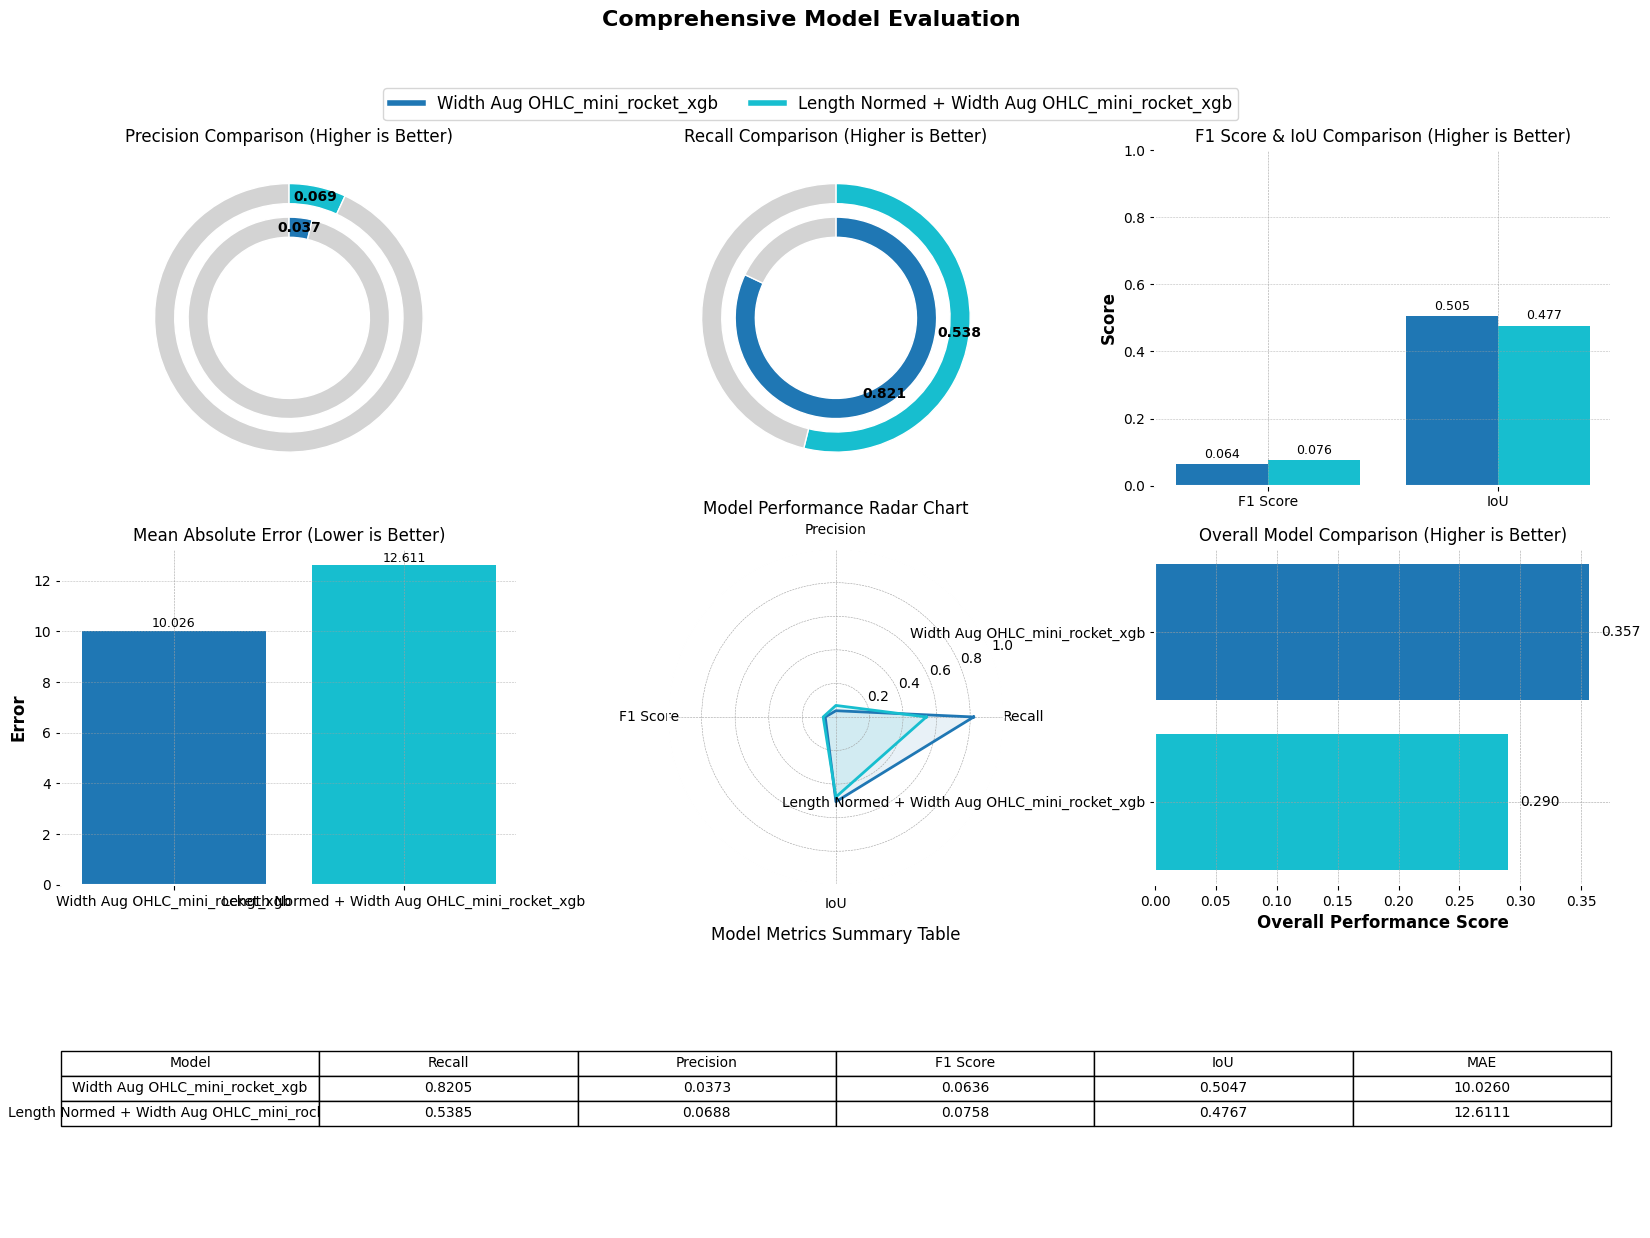

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from utils.eval import evaluate_all_models

all_metrics = evaluate_all_models(model_eval_results_dict, pattern_row_count, test_patterns, located_patterns_and_other_info_dict)
figure = all_metrics[1]

# Parameter Tune


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.formatAndPreprocessNewPatterns import get_pattern_list


In [ ]:
# load the pipelined model
import os
import joblib
from utils.FixedLengthTransformer import FixedLengthTransformer
# load the saved models from the Models directory
model_dir = "Models"
model_files = [f for f in os.listdir(model_dir) if f.endswith('.joblib')]
models = {}
for model_file in model_files:
    model_name = model_file.split('.')[0]
    models[model_name] = joblib.load(os.path.join(model_dir, model_file))
    
# print the model names
print("Available models:")
for model_name in models.keys():
    print(model_name)

selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb','Length Normed + Width Aug OHLC_mini_rocket_xgb']
# selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb']

Available models:
Width Aug OHLC + traindata Aug_mini_rocket_xgb
Width Aug OHLC_rocket_xgb
Width Aug OHLC_mini_rocket_xgb
Width Aug OHLC + traindata Aug_rocket_xgb
Length Normed + Width Aug OHLC_rocket_xgb
Plane OHLC + traindata Aug_mini_rocket_xgb
Width Aug OHLC + traindata Aug_multi_rocket_xgb
Width Aug OHLC_multi_rocket_xgb
Plane OHLC_rocket_xgb
Plane OHLC + traindata Aug_rocket_xgb
Plane OHLC_mini_rocket_xgb
Plane OHLC_multi_rocket_xgb
Length Normed + Width Aug OHLC_mini_rocket_xgb
Plane OHLC + traindata Aug_multi_rocket_xgb
Length Normed + Width Aug OHLC_multi_rocket_xgb
Length Normed OHLC_multi_rocket_xgb
Length Normed OHLC_mini_rocket_xgb
Length Normed OHLC_rocket_xgb


In [ ]:
# load test_seg_ids_adv
import json

with open('Datasets/New_pattern_set_data/Adv_Method2_init/test_seg_ids_adv.json', 'r') as f:
    test_seg_ids_adv = json.load(f)

test_pattern_segment_wise = pd.read_csv("Datasets/New_pattern_set_data/test_patterns_large_segment_wise.csv")
selected_test_pattern_segment_wise_adv = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids_adv)]
# selected_test_pattern_segment_wise_adv = test_pattern_segment_wise.copy()

test_ids_rows_count_sum_adv = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids_adv)].groupby('Seg_ID').size().sum()
test_ids_rows_count_sum_adv , len(test_seg_ids_adv)

(np.int64(124), 100)

In [ ]:
# test_pattern_segment_wise convert Seg_Start , Seg_End , Start and End to datetime
test_pattern_segment_wise.loc[:, 'Seg_Start'] = pd.to_datetime(test_pattern_segment_wise['Seg_Start'])
test_pattern_segment_wise.loc[:, 'Seg_End'] = pd.to_datetime(test_pattern_segment_wise['Seg_End'])
test_pattern_segment_wise.loc[:, 'Start'] = pd.to_datetime(test_pattern_segment_wise['Start'])
test_pattern_segment_wise.loc[:, 'End'] = pd.to_datetime(test_pattern_segment_wise['End'])

In [ ]:
# load the saved csv files to respective dictionaries
located_patterns_and_other_info_dict = {}
window_results_dict = {}

data_dir = "Datasets/New_pattern_set_data/Adv_Method2_init/"
for model_name in selected_models_for_adv:
    located_patterns_and_other_info_df = pd.read_csv(f"{data_dir}located_patterns_and_other_info_{model_name}.csv")
    window_results_df = pd.read_csv(f"{data_dir}window_results_{model_name}.csv")
    
    # convert Start,End and Seg_Start, Seg_End columns to datetime
    window_results_df ['Start'] = pd.to_datetime(window_results_df['Start'])
    window_results_df ['End'] = pd.to_datetime(window_results_df['End'])
    window_results_df['Seg_Start'] = pd.to_datetime(window_results_df['Seg_Start'])
    window_results_df['Seg_End'] = pd.to_datetime(window_results_df['Seg_End'])
    
    # convert Start,End,Seg_Start, Seg_End,Calc_Start, Calc_End columns to datetime
    located_patterns_and_other_info_df ['Start'] = pd.to_datetime(located_patterns_and_other_info_df['Start'])
    located_patterns_and_other_info_df ['End'] = pd.to_datetime(located_patterns_and_other_info_df['End'])
    located_patterns_and_other_info_df['Seg_Start'] = pd.to_datetime(located_patterns_and_other_info_df['Seg_Start'])
    located_patterns_and_other_info_df['Seg_End'] = pd.to_datetime(located_patterns_and_other_info_df['Seg_End'])
    located_patterns_and_other_info_df['Calc_Start'] = pd.to_datetime(located_patterns_and_other_info_df['Calc_Start'])
    located_patterns_and_other_info_df['Calc_End'] = pd.to_datetime(located_patterns_and_other_info_df['Calc_End'])
    
    located_patterns_and_other_info_dict [model_name] = located_patterns_and_other_info_df
    window_results_dict[model_name] = window_results_df
    
    
    

In [ ]:
# window_size = 20
# win_size_proportion = 5
win_size_proportions = np.round(np.logspace(0, np.log10(20), num=10), 2).tolist()
# Example output: [1.0, 1.58, 2.5, 3.95, 6.25, 9.88, 15.63, 20.0]
padding_proportion = 0.6
stride = 1
probability_threshold = 0.0
# for len norm 
target_len = 30

eps=0.04 # in the dbscan clustering
min_samples=3 # in the dbscan clustering
win_width_proportion=10 # in the dbscan clustering from what amount to divide the width related feature

In [ ]:
window_results_df

,Seg_ID,Start,End,Symbol,Chart Pattern,Seg_Start,Seg_End,Probability,Window_Size
0,38,2024-07-08,2024-09-09,BECN,No Pattern,2024-07-08,2024-10-30,0.567937,114
1,38,2024-07-08,2024-09-10,BECN,No Pattern,2024-07-08,2024-10-30,0.366773,114
2,38,2024-07-08,2024-09-11,BECN,Head-and-shoulders top,2024-07-08,2024-10-30,0.444724,114
3,38,2024-07-08,2024-09-12,BECN,No Pattern,2024-07-08,2024-10-30,0.810697,114
4,38,2024-07-08,2024-09-13,BECN,No Pattern,2024-07-08,2024-10-30,0.839186,114
...,...,...,...,...,...,...,...,...,...
63666,248,2020-04-02,2020-04-16,AXDX,No Pattern,2019-12-12,2020-04-17,0.793984,10
63667,248,2020-04-03,2020-04-17,AXDX,No Pattern,2019-12-12,2020-04-17,0.917197,10
63668,248,2020-04-06,2020-04-17,AXDX,No Pattern,2019-12-12,2020-04-17,0.798565,10
63669,248,2020-04-07,2020-04-17,AXDX,No Pattern,2019-12-12,2020-04-17,0.759508,10


In [ ]:
# window_results_df get the number of unique  \Seg_Ids in window_results_df
window_results_df['Seg_ID'].nunique()

100

In [ ]:
import sys

from tqdm import tqdm

from utils.formatAndPreprocessNewPatterns import get_reverse_pattern_encoding
from utils.functionalPatternLocateAndPlot import functional_pattern_filter_and_point_recognition
from utils.patternLocating import  get_ohlc_data_segment, parallel_process_sliding_window, prepare_dataset_for_cluster
from utils.functionalPatternLocateAndPlot import plot_pattern_groups_and_finalized_sections
from utils.patternLocating import cluster_windows
from utils.eval import intersection_over_union

located_patterns_and_other_info_dict_updated = {}
# window_results_dict = {}
pattern_encoding_reversed = get_reverse_pattern_encoding()
path = 'Datasets/OHLC data'

plot_count = 4

for model_name in selected_models_for_adv:
    print(f"Selected model: {model_name}")
    model = models[model_name]
    
    located_patterns_and_other_info_list = []
    window_results_list = []

    # for seg_id, group in tqdm(grouped, desc="Processing segments"):
        
    #     test_seg_id = seg_id  
    for test_seg_id in tqdm(test_seg_ids_adv, desc="Processing test segments"):
        # try :
            # plot_patterns_for_segment(test_seg_id    , test_pattern_segment_wise)
            grouped = test_pattern_segment_wise.groupby('Seg_ID')
            # Select a group
            group = grouped.get_group(test_seg_id)

            Seg_Start = group.iloc[0]['Seg_Start']
            Seg_End = group.iloc[0]['Seg_End']
            seg_len = (Seg_End - Seg_Start).days
            
            win_results_for_each_size = []
            located_patterns_and_other_info_for_each_size = []
            cluster_labled_windows_list = []
            
            used_win_sizes = []
            win_iteration = -1
        
            ohlc_data_segment = get_ohlc_data_segment(test_pattern_segment_wise, test_seg_id, path,group) 
            if ohlc_data_segment is None:
                print("OHLC Data segment is empty")
                continue   
            


            for window_size,win_results_df in window_results_dict[model_name].groupby('Window_Size'):
                # window_size = win_results_df['Window_Size']
                # plot_sliding_steps(win_results_df ,ohlc_data_segment,probability_threshold ,test_seg_id)
                predicted_patterns = prepare_dataset_for_cluster(ohlc_data_segment, win_results_df)
                if predicted_patterns is None:
                    print("Predicted patterns dataframe is empty")
                # print("Predicted Patterns :",predicted_patterns)
                cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, window_size , eps=eps, min_samples=min_samples)
                if cluster_labled_windows_df is None or interseced_clusters_df is None:
                    print("Clustered windows dataframe is empty")
                    continue
                cluster_labled_windows_df['Cluster'] = cluster_labled_windows_df['Cluster'].astype(int) + win_iteration
                win_iteration += 1
                cluster_labled_windows_list.append(cluster_labled_windows_df)
                located_patterns_and_other_info = functional_pattern_filter_and_point_recognition(interseced_clusters_df)
                if located_patterns_and_other_info is None:
                    print("Located patterns and other info dataframe is empty")
                    continue
                # plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, test_seg_id)
                located_patterns_and_other_info['Window_Size'] = window_size
                
                located_patterns_and_other_info_for_each_size.append(located_patterns_and_other_info)
                
            located_patterns_and_other_info_for_each_size_df = pd.concat(located_patterns_and_other_info_for_each_size)
            win_results_for_each_size_df = pd.concat(win_results_for_each_size, ignore_index=True)
            window_results_list.append(win_results_for_each_size_df)
            
            # get the set of unique window sizes from located_patterns_and_other_info_for_each_size_df
            unique_window_sizes = located_patterns_and_other_info_for_each_size_df['Window_Size'].unique()
            unique_patterns = located_patterns_and_other_info_for_each_size_df['Chart Pattern'].unique()    
            
            # sort the unique_window_sizes descending order
            unique_window_sizes = np.sort(unique_window_sizes)[::-1]
            
            filtered_loc_pat_and_info_rows_list = []

            for chart_pattern in unique_patterns:    
                located_patterns_and_other_info_for_each_size_df_chart_pattern = located_patterns_and_other_info_for_each_size_df[located_patterns_and_other_info_for_each_size_df['Chart Pattern'] == chart_pattern]
                for win_size in unique_window_sizes:
                    located_patterns_and_other_info_for_each_size_df_win_size_chart_pattern = located_patterns_and_other_info_for_each_size_df_chart_pattern[located_patterns_and_other_info_for_each_size_df_chart_pattern['Window_Size'] == win_size]
                    for idx , row in located_patterns_and_other_info_for_each_size_df_win_size_chart_pattern.iterrows():
                        start_date = row['Calc_Start']
                        end_date = row['Calc_End']
                        is_already_included = False
                        # check if there are any other rows that intersect with the start and end dates with the same chart pattern
                        intersecting_rows = located_patterns_and_other_info_for_each_size_df_chart_pattern[
                                                            (located_patterns_and_other_info_for_each_size_df_chart_pattern['Calc_Start'] <= end_date) &
                                                            (located_patterns_and_other_info_for_each_size_df_chart_pattern['Calc_End'] >= start_date)
                                                        ]

                        for idx2 , row2 in intersecting_rows.iterrows():
                            # get the IOU of the intersecting rows
                            iou = intersection_over_union(start_date, end_date, row2['Calc_Start'], row2['Calc_End'])
                            if iou > 0.6 and row2['Window_Size'] > row['Window_Size']:
                                is_already_included = True
                                break
                        if not is_already_included:
                            filtered_loc_pat_and_info_rows_list.append(row)
            
            # convert the filtered_loc_pat_and_info_rows_list to a dataframe
            filtered_loc_pat_and_info_df = pd.DataFrame(filtered_loc_pat_and_info_rows_list)
            located_patterns_and_other_info_list.append(filtered_loc_pat_and_info_df) 
            
            cluster_labled_windows_df_conc = pd.concat(cluster_labled_windows_list)
            if plot_count > 0:
                plot_pattern_groups_and_finalized_sections(filtered_loc_pat_and_info_df, cluster_labled_windows_df_conc, test_seg_id)    
                plot_count -= 1          
        # except:
        #     print("Error in segment ID: ",test_seg_id,"error : ",sys.exc_info()[0])
        #     continue

    located_patterns_and_other_info_final_df = pd.concat(located_patterns_and_other_info_list)
    window_results_all_df = pd.concat(window_results_list)
          
    located_patterns_and_other_info_dict_updated[model_name] = located_patterns_and_other_info_final_df
    window_results_dict[model_name] = window_results_all_df

Selected model: Width Aug OHLC_mini_rocket_xgb


Processing test segments:   0%|          | 0/100 [02:08<?, ?it/s]


ValueError: No objects to concatenate

In [ ]:
win_results_df[1]

,Seg_ID,Start,End,Symbol,Chart Pattern,Seg_Start,Seg_End,Probability,Window_Size
497,4,2024-10-25,2024-10-30,CW,No Pattern,2024-10-25,2025-02-08,0.600022,10
498,4,2024-10-25,2024-10-31,CW,No Pattern,2024-10-25,2025-02-08,0.845435,10
499,4,2024-10-25,2024-11-01,CW,No Pattern,2024-10-25,2025-02-08,0.580950,10
500,4,2024-10-25,2024-11-04,CW,Double Bottom,2024-10-25,2025-02-08,0.652682,10
501,4,2024-10-25,2024-11-05,CW,Double Bottom,2024-10-25,2025-02-08,0.842747,10
...,...,...,...,...,...,...,...,...,...
71530,109,2022-10-20,2022-11-02,KMB,No Pattern,2022-06-15,2022-11-03,0.827742,10
71531,109,2022-10-21,2022-11-03,KMB,No Pattern,2022-06-15,2022-11-03,0.785594,10
71532,109,2022-10-24,2022-11-03,KMB,No Pattern,2022-06-15,2022-11-03,0.511417,10
71533,109,2022-10-25,2022-11-03,KMB,No Pattern,2022-06-15,2022-11-03,0.574832,10


In [ ]:
import math
import sys
import os
import pandas as pd
import numpy as np
import itertools
from IPython.display import clear_output
from tqdm import tqdm

from utils.formatAndPreprocessNewPatterns import get_reverse_pattern_encoding
from utils.functionalPatternLocateAndPlot import functional_pattern_filter_and_point_recognition
from utils.patternLocating import get_ohlc_data_segment, parallel_process_sliding_window, prepare_dataset_for_cluster
from utils.functionalPatternLocateAndPlot import plot_pattern_groups_and_finalized_sections
from utils.patternLocating import cluster_windows
from utils.eval import intersection_over_union, get_model_eval_res, evaluate_all_models

# Create directories for results if they don't exist
if not os.path.exists("Pattern_Tuning_Results"):
    os.makedirs("Pattern_Tuning_Results")
    os.makedirs("Pattern_Tuning_Results/Plots")
    os.makedirs("Pattern_Tuning_Results/Dataframe")

# Load all the saved csv files into dicts
located_patterns_and_other_info_dict = {}
window_results_dict = {}
selected_models = ['Plane OHLC_mini_rocket_xgb', 'Length Normed OHLC_mini_rocket_xgb', 
                  'Width Aug OHLC_mini_rocket_xgb', 'Length Normed + Width Aug OHLC_mini_rocket_xgb']

for model_name in selected_models:
    located_patterns_and_other_info_dict[model_name] = pd.read_csv(f"Datasets/New_pattern_set_data/1stRun/located_patterns_and_other_info_{model_name}.csv")
    window_results_dict[model_name] = pd.read_csv(f"Datasets/New_pattern_set_data/1stRun/window_results_{model_name}.csv")

# Load test data
test_pattern_segment_wise = pd.read_csv("Datasets/New_pattern_set_data/selected_test_pattern_segment_wise.csv")
pattern_encoding_reversed = get_reverse_pattern_encoding()
path = 'Datasets/OHLC data'

# Get test segments
test_seg_ids_adv = test_pattern_segment_wise['Seg_ID'].unique()

# Calculate pattern row count
pattern_row_count = {}
chart_patterns = get_pattern_list()
for pattern in chart_patterns:  # Assuming chart_patterns is defined elsewhere
    pattern_row_count[pattern] = test_pattern_segment_wise[test_pattern_segment_wise['Chart Pattern'] == pattern].shape[0]

# Define parameter ranges to tune
probability_thresholds = [round(x, 1) for x in np.arange(0.1, 1.0, 0.1)]
eps_values = [round(x, 1) for x in np.arange(0.1, 1.0, 0.1)]
min_samples_values = list(range(2, 11))

all_metrics_list = []

# Use itertools for cleaner parameter iteration
parameter_combinations = list(itertools.product(probability_thresholds, eps_values, min_samples_values))
total_combinations = len(parameter_combinations)

# Main loop with output clearing
for i, (probability_threshold, eps, min_samples) in enumerate(parameter_combinations):
    # Clear previous outputs to avoid cluttering the notebook
    clear_output(wait=True)
    
    # Show progress information
    print(f"Progress: {i+1}/{total_combinations} combinations ({((i+1)/total_combinations)*100:.1f}%)")
    print(f"Parameters: probability_threshold={probability_threshold:.1f}, eps={eps:.1f}, min_samples={min_samples}")
    
    located_patterns_and_other_info_dict_updated = {}
    
    for model_name in selected_models:
        print(f"Processing model: {model_name}")
        
        located_patterns_and_other_info_list = []
        window_results_list = []
        
        # Track segment processing with a progress bar
        seg_counter = 0
        
        for test_seg_id in tqdm(test_seg_ids_adv[:50], desc=f"Processing segments for {model_name}"):  # Limiting to first 50 segments for efficiency
            seg_counter += 1
            
            try:
                # Get the group data for this segment ID
                grouped = test_pattern_segment_wise.groupby('Seg_ID')
                group = grouped.get_group(test_seg_id)
                
                Seg_Start = group.iloc[0]['Seg_Start']
                Seg_End = group.iloc[0]['Seg_End']
                seg_len = (Seg_End - Seg_Start).days
                
                # Get OHLC data for this segment
                ohlc_data_segment = get_ohlc_data_segment(test_pattern_segment_wise, test_seg_id, path, group)
                if ohlc_data_segment is None:
                    continue
                
                win_results_for_each_size = []
                located_patterns_and_other_info_for_each_size = []
                cluster_labled_windows_list = []
                
                win_iteration = -1
                
                # Process each window size for this segment
                for win_size, win_results_df in window_results_dict[model_name].groupby('Window_Size'):
                    # Prepare dataset for clustering
                    predicted_patterns = prepare_dataset_for_cluster(ohlc_data_segment, win_results_df)
                    if predicted_patterns is None or predicted_patterns.empty:
                        continue
                    
                    # Apply clustering with tuned parameters
                    cluster_labled_windows_df, interseced_clusters_df = cluster_windows(
                        predicted_patterns, 
                        probability_threshold, 
                        win_size, 
                        eps=eps, 
                        min_samples=min_samples
                    )
                    
                    if cluster_labled_windows_df is None or interseced_clusters_df is None:
                        continue
                    
                    # Adjust cluster IDs to avoid overlap between window sizes
                    cluster_labled_windows_df['Cluster'] = cluster_labled_windows_df['Cluster'].astype(int) + win_iteration
                    win_iteration += 1
                    cluster_labled_windows_list.append(cluster_labled_windows_df)
                    
                    # Get pattern information
                    located_patterns_and_other_info = functional_pattern_filter_and_point_recognition(interseced_clusters_df)
                    if located_patterns_and_other_info is None or located_patterns_and_other_info.empty:
                        continue
                    
                    # Filter out 'No Pattern' entries
                    located_patterns_and_other_info = located_patterns_and_other_info[
                        located_patterns_and_other_info['Chart Pattern'] != 'No Pattern'
                    ]
                    
                    if located_patterns_and_other_info.empty:
                        continue
                        
                    # Add window size information
                    located_patterns_and_other_info['Window_Size'] = win_size
                    located_patterns_and_other_info_for_each_size.append(located_patterns_and_other_info)
                    win_results_for_each_size.append(win_results_df)
                
                # Skip if no valid patterns found for any window size
                if not located_patterns_and_other_info_for_each_size:
                    continue
                
                # Concatenate results from all window sizes
                located_patterns_and_other_info_for_each_size_df = pd.concat(located_patterns_and_other_info_for_each_size)
                win_results_for_each_size_df = pd.concat(win_results_for_each_size, ignore_index=True)
                window_results_list.append(win_results_for_each_size_df)
                
                # Filter overlapping patterns based on window size and IOU
                unique_window_sizes = np.sort(located_patterns_and_other_info_for_each_size_df['Window_Size'].unique())[::-1]
                unique_patterns = located_patterns_and_other_info_for_each_size_df['Chart Pattern'].unique()
                
                filtered_loc_pat_and_info_rows_list = []
                
                for chart_pattern in unique_patterns:
                    pattern_df = located_patterns_and_other_info_for_each_size_df[
                        located_patterns_and_other_info_for_each_size_df['Chart Pattern'] == chart_pattern
                    ]
                    
                    for win_size in unique_window_sizes:
                        win_pattern_df = pattern_df[pattern_df['Window_Size'] == win_size]
                        
                        for idx, row in win_pattern_df.iterrows():
                            start_date = row['Calc_Start']
                            end_date = row['Calc_End']
                            is_already_included = False
                            
                            # Check for overlapping patterns with same chart pattern
                            intersecting_rows = pattern_df[
                                (pattern_df['Calc_Start'] <= end_date) &
                                (pattern_df['Calc_End'] >= start_date)
                            ]
                            
                            for idx2, row2 in intersecting_rows.iterrows():
                                # Calculate IOU and check if current pattern is already covered by a larger window
                                iou = intersection_over_union(start_date, end_date, row2['Calc_Start'], row2['Calc_End'])
                                if iou > 0.6 and row2['Window_Size'] > row['Window_Size']:
                                    is_already_included = True
                                    break
                                    
                            if not is_already_included:
                                filtered_loc_pat_and_info_rows_list.append(row)
                
                # Convert filtered results to dataframe
                if filtered_loc_pat_and_info_rows_list:
                    filtered_loc_pat_and_info_df = pd.DataFrame(filtered_loc_pat_and_info_rows_list)
                    located_patterns_and_other_info_list.append(filtered_loc_pat_and_info_df)
                
            except Exception as e:
                print(f"Error processing segment {test_seg_id}: {str(e)}")
                continue
        
        print(f"Completed processing for model: {model_name}")
        
        # Combine results for this model
        if located_patterns_and_other_info_list:
            located_patterns_and_other_info_final_df = pd.concat(located_patterns_and_other_info_list)
            located_patterns_and_other_info_dict_updated[model_name] = located_patterns_and_other_info_final_df
        else:
            print(f"Warning: No valid patterns found for model {model_name} with these parameters")
            located_patterns_and_other_info_dict_updated[model_name] = pd.DataFrame()  # Empty dataframe
    
    # Evaluate models with current parameters
    try:
        model_eval_results_dict = get_model_eval_res(located_patterns_and_other_info_dict_updated, window_results_dict, selected_models)
        all_metrics = evaluate_all_models(model_eval_results_dict, pattern_row_count, test_patterns, located_patterns_and_other_info_dict_updated)
        figure = all_metrics[1]
        
        # Save plot
        plot_path = f"Pattern_Tuning_Results/Plots/Model_Comparison_prob-{probability_threshold:.1f}_eps-{eps:.1f}_min_samples-{min_samples}_models-{selected_models}.png"
        figure.savefig(plot_path, bbox_inches='tight')
        
        # Convert metrics to dataframe
        all_metrics_df = pd.DataFrame(all_metrics[0]).T
        all_metrics_df.reset_index(drop=False, inplace=True)
        all_metrics_df.rename(columns={'index': 'Model'}, inplace=True)
        
        # Add parameter information
        all_metrics_df['probability_threshold'] = round(probability_threshold, 1)
        all_metrics_df['eps'] = round(eps, 1)
        all_metrics_df['min_samples'] = min_samples
        all_metrics_df['plot_path'] = plot_path
        
        # Save individual parameter combination results
        csv_path = f"Pattern_Tuning_Results/Dataframe/Model_Comparison_prob-{probability_threshold:.1f}_eps-{eps:.1f}_min_samples-{min_samples}_models-{selected_models}.csv"
        all_metrics_df.to_csv(csv_path, index=False)
        all_metrics_list.append(all_metrics_df)
        
        print(f"Saved results for parameters: prob={probability_threshold:.1f}, eps={eps:.1f}, min_samples={min_samples}")
    except Exception as e:
        print(f"Error evaluating models with parameters {probability_threshold:.1f}, {eps:.1f}, {min_samples}: {str(e)}")
        continue

# Final summary after all processing is complete
clear_output(wait=True)
print("All parameter combinations processed!")
print(f"Total successful combinations: {len(all_metrics_list)}/{total_combinations}")

# Combine all results
if all_metrics_list:
    all_metrics_df_conc = pd.concat(all_metrics_list)
    all_metrics_df_conc.to_csv(f"Pattern_Tuning_Results/Dataframe/Comprehensive_Model_Comparison_All.csv", index=False)
    
    # Display summary of best parameters per model
    print("\nSummary of best parameters per model:")
    for model in selected_models:
        model_metrics = all_metrics_df_conc[all_metrics_df_conc['Model'] == model]
        if not model_metrics.empty:
            # Assuming F1-score is the primary metric for selection
            best_params = model_metrics.loc[model_metrics['F1-Score'].idxmax()]
            print(f"\nBest parameters for {model}:")
            print(f"  Probability threshold: {best_params['probability_threshold']}")
            print(f"  Eps: {best_params['eps']}")
            print(f"  Min samples: {best_params['min_samples']}")
            print(f"  F1-Score: {best_params['F1-Score']:.4f}")
            print(f"  Precision: {best_params['Precision']:.4f}")
            print(f"  Recall: {best_params['Recall']:.4f}")
    
    display(all_metrics_df_conc.head())  # Show a preview of the results
else:
    print("No successful parameter combinations found.")

All parameter combinations processed!
Total successful combinations: 0/729
No successful parameter combinations found.


In [ ]:
window_results_dict

{}